# Valoración de la cartera "Lending Club" para adquisición.

Nuestra entidad está evaluando la compra de una cartera de créditos al consumo originada por la plataforma Lending Club. El equipo de Inversiones está emocionado porque los tipos de interés de estos préstamos parecen muy rentables. Sin embargo, desde el departamento de Riesgos y bajo la atenta mirada del regulador, sabemos que la rentabilidad no es nada si no somos capaces de estimar el riesgo real de impago y la pérdida económica que nos va a suponer.

No voy a aprobar esta compra basándome en intuiciones. Necesito que construyáis un motor de Credit Scoring y Valoración de Pérdida Esperada (Expected Loss) desde cero.

Vuestro objetivo final no es entregarme un modelo con un buen "Accuracy". Vuestro objetivo es darme una cifra en euros: ¿Cuánto dinero estimamos que vamos a perder de esta cartera?

Para ello, tendréis que calcular la fórmula reina del riesgo de crédito:

$$
Pérdida Esperada (EL) = PD × LGD × EAD
$$


## 🗺️ Tu Misión (Hoja de Ruta)

El proyecto se divide en 4 fases críticas. Deberéis documentar cada decisión que toméis. Si borráis nulos o agrupáis categorías, quiero saber por qué lo hacéis desde el punto de vista de negocio. Podéis utilizar cualquier modelo de Machine Learning que consideréis oportuno para cada fase.

### Fase 1: Limpieza de Datos y Definición del Problema (Data Preparation)
El archivo que nos han enviado desde Lending Club tiene datos de clientes reales. Eso significa ruido, valores atípicos y nulos.

- Análisis Exploratorio (EDA): Identificad qué variables tenemos. ¿Hay desbalanceo? ¿Qué hacemos con las profesiones raras o los valores extremos en ingresos?

**Definición de los Parámetros de Riesgo:**

- PD (Probability of Default): Se calculará como una probabilidad matemática sin más. Deberéis crear una variable objetivo binaria (0/1) a partir del estado del préstamo, donde los impagados son un 1 y los pagados un 0.

- LGD (Loss Given Default / Severidad): Para calcular la pérdida real, utilizaréis la siguiente fórmula exacta en vuestro código:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ``df['Loss'] = 100 * df['max_bal_owed'] / df['funded_amnt']``

- EAD (Exposure At Default): La exposición será directamente la cantidad financiada inicial (``funded_amnt``).


### Diccionario de Datos: Cartera Lending Club

| Variable Original | Nombre en Español | Definición Técnica |
| :--- | :--- | :--- |
| `funded_amnt` | **monto_financiado** | Monto total comprometido para el préstamo en el momento de la emisión. |
| `interest_rate` | **tasa_interes** | Tasa de interés anual del préstamo. |
| `monthly_payment` | **pago_mensual** | Cuota mensual que el prestatario debe pagar si el préstamo se origina. |
| `grade` | **grado** | Calificación de riesgo asignada por Lending Club (de A5 a C1). |
| `loan_term_months` | **plazo_prestamo_meses** | Duración del préstamo en meses (ej. 36 o 60). |
| `loan_purpose` | **proposito_prestamo** | Categoría del motivo del préstamo (deuda, mejoras hogar, etc.). |
| `disbursement_method` | **metodo_desembolso** | Forma en que se entregó el dinero (Efectivo o Pago Directo). |
| `issue_date_month` | **mes_emision** | Mes en el que se financió el préstamo. |
| `issue_date_year` | **anio_emision** | Año en el que se financió el préstamo. |
| `emp_title` | **titulo_empleo** | Puesto de trabajo proporcionado por el prestatario. |
| `emp_length` | **antiguedad_empleo** | Años de experiencia laboral (0 a 10+ años). |
| `home_ownership_status` | **estado_vivienda** | Situación de la vivienda (Renta, Propia, Hipoteca). |
| `annual_income` | **ingreso_anual** | Ingresos anuales declarados por el prestatario. |
| `verification_status` | **estado_verificacion** | Indica si los ingresos fueron verificados por la plataforma. |
| `addr_state` | **estado_residencia** | Estado de EE.UU. donde reside el prestatario. |
| `region_code` | **codigo_region** | Código numérico de la región geográfica. |
| `dept_paym_income_ratio` | **ratio_deuda_ingresos** | Porcentaje de ingresos que se destinan al pago de deudas (DTI). |
| `num_30+_delinq_in_2yrs` | **num_moras_30_dias_2anios** | Veces que ha incurrido en mora de 30+ días en los últimos 2 años. |
| `num_inq_in_6mths` | **num_consultas_6meses** | Consultas de crédito en los últimos 6 meses (excl. automotrices). |
| `num_inq_in_12mths` | **num_consultas_12meses** | Consultas de crédito en los últimos 12 meses. |
| `num_inq` | **num_consultas_totales** | Total de consultas de crédito registradas en su historial. |
| `mths_since_last_delinq` | **meses_desde_ultima_mora** | Tiempo transcurrido desde la última mora registrada. |
| `num_open_credit_lines` | **num_lineas_credito_abiertas** | Número de líneas de crédito activas actualmente. |
| `num_derogatory_pub_rec` | **num_registros_negativos** | Número de registros públicos desfavorables (quiebras, etc.). |
| `total_credit_revolving_bal` | **saldo_revolvente_total** | Saldo total en tarjetas de crédito y líneas revolventes. |
| `used_credit_share` | **porcentaje_credito_utilizado** | Ratio de saldo revolvente sobre el límite de crédito total. |
| `tot_num_credit_lines` | **num_total_lineas_credito** | Total de líneas de crédito que ha tenido el cliente. |
| `initial_list_status` | **estado_listado_inicial** | Estado inicial del listado del préstamo (W o F). |
| `earliest_cr_line_month` | **mes_primera_linea_credito** | Mes en que se abrió la primera línea de crédito reportada. |
| `earliest_cr_line_year` | **anio_primera_linea_credito** | Año en que se abrió la primera línea de crédito reportada. |
| `remaining_princ_for_tot_amnt_fund` | **capital_pendiente_total** | Capital que aún no se ha recuperado del monto financiado. |
| `paym_rec_for_tot_amnt_fund` | **pagos_recibidos_total** | Total de pagos (capital + interés) recibidos hasta hoy. |
| `princ_rec` | **capital_recibido** | Solo el capital que ha sido recuperado hasta la fecha. |
| `interest_rec` | **intereses_recibidos** | Solo los intereses recuperados hasta la fecha. |
| `late_fees_rec` | **comisiones_mora_recibidas** | Comisiones por pagos atrasados recolectadas. |
| `max_bal_owed` | **saldo_maximo_adeudado** | El saldo máximo que el cliente ha llegado a deber. |
| `bal_to_cred_lim` | **saldo_vs_limite_credito** | Saldo actual frente al límite total de sus cuentas revolventes. |
| `num_open_trades_in_6mths` | **num_operaciones_abiertas_6meses** | Cuentas de crédito abiertas en el último semestre. |
| `num_installment_acc_op_in_12mths` | **num_cuentas_cuotas_12meses** | Apertura de cuentas a plazos en el último año. |
| `num_installment_acc_op_in_24mths` | **num_cuentas_cuotas_24meses** | Apertura de cuentas a plazos en los últimos 2 años. |
| `mths_since_last_installment_acc_op` | **meses_desde_ultima_cuenta_cuotas** | Tiempo desde que se abrió la última cuenta a plazos. |
| `num_rev_trades_op_in_12mths` | **num_operaciones_revolventes_12meses** | Cuentas revolventes abiertas en el último año. |
| `num_rev_trades_op_in_24mths` | **num_operaciones_revolventes_24meses** | Cuentas revolventes abiertas en los últimos 2 años. |
| `mths_since_recent_bankcard_delinq` | **meses_desde_ultima_mora_bancaria** | Tiempo desde la última mora en tarjetas de crédito. |
| `mths_since_recent_revol_delinq` | **meses_desde_ultima_mora_revolvente** | Tiempo desde la última mora en líneas revolventes. |
| `y` | **target_moroso** | **Variable Objetivo:** 1 si el cliente incumplió el pago, 0 si no. |


In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
import math
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV

## ⚙️ Panel de Control del Modelo
Configura estas variables para controlar el comportamiento del notebook. 

*   **`PORCENTAJE_DATOS`**: Define la escala del dataset. 
    *   `1.0`: Dataset completo (~2.1M filas). Recomendado para resultados finales (24GB RAM).
    *   `0.1`: Muestra del 10%. Ideal para pruebas rápidas de código.
*   **`MODO_COMPLETO`**: Define la profundidad del entrenamiento.
    *   `True`: Ejecuta una optimización (RandomizedSearch) sobre los 4 modelos (XGBoost, Random Forest, etc.).
    *   `False`: **Modo Champion**. Entrena solo la Regresión Logística optimizada en segundos.


In [2]:
# --- CONFIGURACIÓN DE DATOS ---

# Volumen de datos: 1.0 = 100%, 0.1 = 10%
PORCENTAJE_DATOS = 0.1

# Tipo de ejecución: True = Optimiza 4 modelos, False = Solo Regresión Logística (Rápido)
MODO_COMPLETO = False 

In [3]:
# Importamos los archivos a dataframes

traducciones = {
    # Variables de identificación y préstamo
    'funded_amnt': 'monto_financiado',
    'interest_rate': 'tasa_interes',
    'monthly_payment': 'pago_mensual',
    'grade': 'grado',
    'loan_term_months': 'plazo_prestamo_meses',
    'loan_purpose': 'proposito_prestamo',
    'disbursement_method': 'metodo_desembolso',
    'issue_date_month': 'mes_emision',
    'issue_date_year': 'anio_emision',
    
    # Datos del prestatario
    'emp_title': 'titulo_empleo',
    'emp_length': 'antiguedad_empleo',
    'home_ownership_status': 'estado_vivienda',
    'annual_income': 'ingreso_anual',
    'verification_status': 'estado_verificacion',
    'addr_state': 'estado_residencia',
    'region_code': 'codigo_region',
    
    # Historial Crediticio y Comportamiento
    'dept_paym_income_ratio': 'ratio_deuda_ingresos',
    'num_30+_delinq_in_2yrs': 'num_moras_30_dias_2anios',
    'num_inq_in_6mths': 'num_consultas_6meses',
    'num_inq_in_12mths': 'num_consultas_12meses',
    'num_inq': 'num_consultas_totales',
    'mths_since_last_delinq': 'meses_desde_ultima_mora',
    'num_open_credit_lines': 'num_lineas_credito_abiertas',
    'num_derogatory_pub_rec': 'num_registros_negativos',
    'total_credit_revolving_bal': 'saldo_revolvente_total',
    'used_credit_share': 'porcentaje_credito_utilizado',
    'tot_num_credit_lines': 'num_total_lineas_credito',
    'initial_list_status': 'estado_listado_inicial',
    'earliest_cr_line_month': 'mes_primera_linea_credito',
    'earliest_cr_line_year': 'anio_primera_linea_credito',
    
    # Operaciones y Saldos
    'remaining_princ_for_tot_amnt_fund': 'capital_pendiente_total',
    'paym_rec_for_tot_amnt_fund': 'pagos_recibidos_total',
    'princ_rec': 'capital_recibido',
    'interest_rec': 'intereses_recibidos',
    'late_fees_rec': 'comisiones_mora_recibidas',
    'max_bal_owed': 'saldo_maximo_adeudado',
    'bal_to_cred_lim': 'saldo_vs_limite_credito',
    
    # Cuentas Específicas
    'num_open_trades_in_6mths': 'num_operaciones_abiertas_6meses',
    'num_installment_acc_op_in_12mths': 'num_cuentas_cuotas_12meses',
    'num_installment_acc_op_in_24mths': 'num_cuentas_cuotas_24meses',
    'mths_since_last_installment_acc_op': 'meses_desde_ultima_cuenta_cuotas',
    'num_rev_trades_op_in_12mths': 'num_operaciones_revolventes_12meses',
    'num_rev_trades_op_in_24mths': 'num_operaciones_revolventes_24meses',
    'mths_since_recent_bankcard_delinq': 'meses_desde_ultima_mora_bancaria',
    'mths_since_recent_revol_delinq': 'meses_desde_ultima_mora_revolvente',
    
    # Variable Objetivo
    'y': 'target_moroso'
}

# Variable moroso/NO moroso
y = pd.read_csv('data/target.csv')

# Covariables predictoras
df_full = pd.read_csv('data/x.csv')

# Unificamos los dataframes
df_full = pd.concat([df_full, y], axis=1)

# Aplicamos las traducciones definidas
df_full.rename(columns=traducciones, inplace=True)

# Aplicamos Muestreo Estratificado para quedarnos con un 10% (0.10)
if PORCENTAJE_DATOS < 1.0:
    # Si es menor a 1.0, aplicamos el muestreo
    df, _ = train_test_split(
        df_full, 
        train_size=PORCENTAJE_DATOS, 
        stratify=df_full['target_moroso'], 
        random_state=42
    )
    print(f"Trabajando con una muestra del {PORCENTAJE_DATOS*100}% ({df.shape[0]} filas)")
else:
    # Si es 1.0, usamos el dataset COMPLETO
    df = df_full.copy()
    print(f"Trabajando con el dataset COMPLETO ({df.shape[0]} filas)")
df = df.reset_index(drop=True)

print(df.info())


Trabajando con una muestra del 10.0% (213964 filas)
<class 'pandas.DataFrame'>
RangeIndex: 213964 entries, 0 to 213963
Data columns (total 46 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   monto_financiado                     213964 non-null  int64  
 1   tasa_interes                         213964 non-null  float64
 2   pago_mensual                         213964 non-null  float64
 3   grado                                213964 non-null  str    
 4   titulo_empleo                        198965 non-null  str    
 5   antiguedad_empleo                    200779 non-null  str    
 6   estado_vivienda                      213964 non-null  str    
 7   ingreso_anual                        213964 non-null  float64
 8   estado_verificacion                  213964 non-null  str    
 9   proposito_prestamo                   213964 non-null  str    
 10  estado_residencia                    21

In [4]:
# Mapeamos los nombres y calculamos porcentajes
distribucion = df['target_moroso'].value_counts(normalize=True) * 100

print(f"Buen Pagador (0): {distribucion[0]:.2f}%")
print(f"Moroso       (1): {distribucion[1]:.2f}%")


Buen Pagador (0): 86.93%
Moroso       (1): 13.07%


In [5]:
# Mostrar columnas con nulos y su porcentaje
nulos = df.isnull().mean() * 100

print("--- Porcentaje de vaores nulos por columna ---")
print(nulos[nulos > 0].sort_values(ascending=False))

--- Porcentaje de vaores nulos por columna ---
meses_desde_ultima_mora_bancaria       76.838627
meses_desde_ultima_mora_revolvente     67.068759
meses_desde_ultima_mora                50.955301
meses_desde_ultima_cuenta_cuotas       42.274869
saldo_vs_limite_credito                40.430166
num_operaciones_abiertas_6meses        40.425492
saldo_maximo_adeudado                  40.425492
num_operaciones_revolventes_24meses    40.425492
num_cuentas_cuotas_24meses             40.425492
num_cuentas_cuotas_12meses             40.425492
num_operaciones_revolventes_12meses    40.425492
num_consultas_totales                  40.425492
titulo_empleo                           7.010058
antiguedad_empleo                       6.162252
dtype: float64


In [6]:
# Calculamos los porcentajes de nulos
nulos_por_grupo = df.groupby('target_moroso')['saldo_maximo_adeudado'].apply(lambda x: x.isnull().mean() * 100)

# Lo mostramos de forma elegante
print("--- ANÁLISIS DE HUECOS EN SALDO MÁXIMO ---")
for grupo, porcentaje in nulos_por_grupo.items():
    nombre = "Morosos (1)" if grupo == 1 else "Pagadores (0)"
    print(f"{nombre:<15}: {porcentaje:>6.2f}% de datos faltantes")


--- ANÁLISIS DE HUECOS EN SALDO MÁXIMO ---
Pagadores (0)  :  38.34% de datos faltantes
Morosos (1)    :  54.27% de datos faltantes


In [7]:
# Imputar saldo_maximo_adeudado con la mediana de su 'grado'
df['saldo_maximo_adeudado'] = df.groupby('grado')['saldo_maximo_adeudado'].transform(lambda x: x.fillna(x.median()))


# Imputar saldo_vs_limite_credito con la mediana de su 'grado'
df['saldo_vs_limite_credito'] = df.groupby('grado')['saldo_vs_limite_credito'].transform(lambda x: x.fillna(x.median()))

# Verificamos si aún quedan nulos (por si algún grado estuviera todo vacío)
print(f"Nulos restantes en saldo_maximo_adeudado: {df['saldo_maximo_adeudado'].isnull().sum()}")
print(f"Nulos restantes en saldo_vs_limite_credito: {df['saldo_vs_limite_credito'].isnull().sum()}")

Nulos restantes en saldo_maximo_adeudado: 0
Nulos restantes en saldo_vs_limite_credito: 0


In [8]:
# Variables de tiempo (Meses desde...) -> 999 (Nunca ocurrió)
vars_tiempo = [
    'meses_desde_ultima_mora_bancaria', 
    'meses_desde_ultima_mora_revolvente', 
    'meses_desde_ultima_mora', 
    'meses_desde_ultima_cuenta_cuotas'
]

for col in vars_tiempo:
    df[f'flag_{col}_na'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(0) # Previamnte 999, pero descartado porque con el flag se infiere se valida si es inferida o real

# Variables de conteo -> 0 (Asumimos que no hubo consultas/operaciones)
vars_conteo = [
    'num_consultas_totales',
    'num_operaciones_abiertas_6meses',
    'num_operaciones_revolventes_12meses',
    'num_operaciones_revolventes_24meses',
    'num_cuentas_cuotas_12meses',
    'num_cuentas_cuotas_24meses'
]
df[vars_conteo] = df[vars_conteo].fillna(0)

In [9]:
# Imputación de variables categóricas en inglés
df['titulo_empleo'] = df['titulo_empleo'].fillna('Unknown')
df['antiguedad_empleo'] = df['antiguedad_empleo'].fillna('Unknown')

# Verificación final de que no quedan nulos en todo el DataFrame
total_nulos = df.isnull().sum().sum()
print(f"Total de nulos en el DataFrame: {total_nulos}")

Total de nulos en el DataFrame: 0


In [10]:
# Creamos la variable derivada (necesita las originales antes de borrarlas)
df['anios_historial_crediticio'] = df['anio_emision'] - df['anio_primera_linea_credito']

# Eliminamos las variables que ya no necesitamos
cols_a_eliminar = ['anio_emision', 'anio_primera_linea_credito', 'mes_emision', 'mes_primera_linea_credito']
df.drop(columns=cols_a_eliminar, inplace=True)

# Identificamos tipos de variables (ahora ya vendrán sin las eliminadas)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=[object]).columns.tolist()

# 4. Reorganizamos codigo_region (de numérica a categórica)
if 'codigo_region' in num_cols:
    num_cols.remove('codigo_region')
    cat_cols.append('codigo_region')

# Eliminamos de las variables numericas la variable predictiva
num_cols.remove('target_moroso')

print(f"Variables Numéricas ({len(num_cols)}): {num_cols}\n")
print(f"Variables Categóricas ({len(cat_cols)}): {cat_cols}")

Variables Numéricas (36): ['monto_financiado', 'tasa_interes', 'pago_mensual', 'ingreso_anual', 'ratio_deuda_ingresos', 'num_moras_30_dias_2anios', 'num_consultas_6meses', 'meses_desde_ultima_mora', 'num_lineas_credito_abiertas', 'num_registros_negativos', 'saldo_revolvente_total', 'porcentaje_credito_utilizado', 'num_total_lineas_credito', 'capital_pendiente_total', 'pagos_recibidos_total', 'capital_recibido', 'intereses_recibidos', 'comisiones_mora_recibidas', 'num_operaciones_abiertas_6meses', 'num_cuentas_cuotas_12meses', 'num_cuentas_cuotas_24meses', 'meses_desde_ultima_cuenta_cuotas', 'num_operaciones_revolventes_12meses', 'num_operaciones_revolventes_24meses', 'saldo_maximo_adeudado', 'saldo_vs_limite_credito', 'num_consultas_totales', 'num_consultas_12meses', 'meses_desde_ultima_mora_bancaria', 'meses_desde_ultima_mora_revolvente', 'plazo_prestamo_meses', 'flag_meses_desde_ultima_mora_bancaria_na', 'flag_meses_desde_ultima_mora_revolvente_na', 'flag_meses_desde_ultima_mora_na',

C:\Users\jrglo\AppData\Local\Temp\ipykernel_21348\2123095887.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=[object]).columns.tolist()


In [11]:
# Configurar Pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Ahora ya puedes verlas todas
df.head()


,monto_financiado,tasa_interes,pago_mensual,grado,titulo_empleo,antiguedad_empleo,estado_vivienda,ingreso_anual,estado_verificacion,proposito_prestamo,estado_residencia,ratio_deuda_ingresos,num_moras_30_dias_2anios,num_consultas_6meses,meses_desde_ultima_mora,num_lineas_credito_abiertas,num_registros_negativos,saldo_revolvente_total,porcentaje_credito_utilizado,num_total_lineas_credito,estado_listado_inicial,capital_pendiente_total,pagos_recibidos_total,capital_recibido,intereses_recibidos,comisiones_mora_recibidas,num_operaciones_abiertas_6meses,num_cuentas_cuotas_12meses,num_cuentas_cuotas_24meses,meses_desde_ultima_cuenta_cuotas,num_operaciones_revolventes_12meses,num_operaciones_revolventes_24meses,saldo_maximo_adeudado,saldo_vs_limite_credito,num_consultas_totales,num_consultas_12meses,meses_desde_ultima_mora_bancaria,meses_desde_ultima_mora_revolvente,metodo_desembolso,plazo_prestamo_meses,codigo_region,target_moroso,flag_meses_desde_ultima_mora_bancaria_na,flag_meses_desde_ultima_mora_revolvente_na,flag_meses_desde_ultima_mora_na,flag_meses_desde_ultima_cuenta_cuotas_na,anios_historial_crediticio
0,13000,7.97,407.20,A5,Accounting Analyst,2 years,RENT,60000.0,Source Verified,debt_consolidation,NJ,22.72,0,0,27.0,12,0,5177,20.8,14,w,7956.79,6110.890000,5043.21,1067.68,0.0,0.0,1.0,2.0,9.0,0.0,0.0,4739.0,60.0,1.0,0,0.0,0.0,Cash,36,0,0,1,1,0,0,6
1,21000,21.45,796.04,D5,Teacher,10+ years,MORTGAGE,55000.0,Verified,debt_consolidation,TN,31.99,1,1,7.0,9,0,30375,80.8,39,w,0.00,8734.800000,3575.20,2743.07,39.8,1.0,2.0,7.0,2.0,1.0,1.0,2831.0,72.0,1.0,3,0.0,7.0,Cash,36,3,1,1,0,0,0,21
2,11000,14.65,379.44,C2,United States Coast Guard,3 years,RENT,36000.0,Source Verified,credit_card,CA,12.57,0,0,0.0,3,0,13129,71.0,4,f,0.00,13659.660005,11000.00,2659.66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4309.0,61.0,0.0,0,0.0,0.0,Cash,36,9,0,1,1,1,1,6
3,16000,6.72,491.99,A3,Team member,2 years,RENT,58000.0,Source Verified,credit_card,NJ,7.66,0,1,0.0,2,0,11176,74.5,12,w,10589.51,6383.920000,5410.49,973.43,0.0,0.0,1.0,1.0,9.0,0.0,0.0,11176.0,75.0,0.0,1,0.0,0.0,Cash,36,0,0,1,1,1,0,31
4,10325,8.18,324.41,B1,Senior Social Service Worker,5 years,MORTGAGE,35000.0,Not Verified,credit_card,NY,24.62,0,0,0.0,11,0,9546,18.7,18,w,0.00,11372.142288,10325.00,1047.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4478.0,53.0,0.0,0,0.0,0.0,Cash,36,1,0,1,1,1,1,14


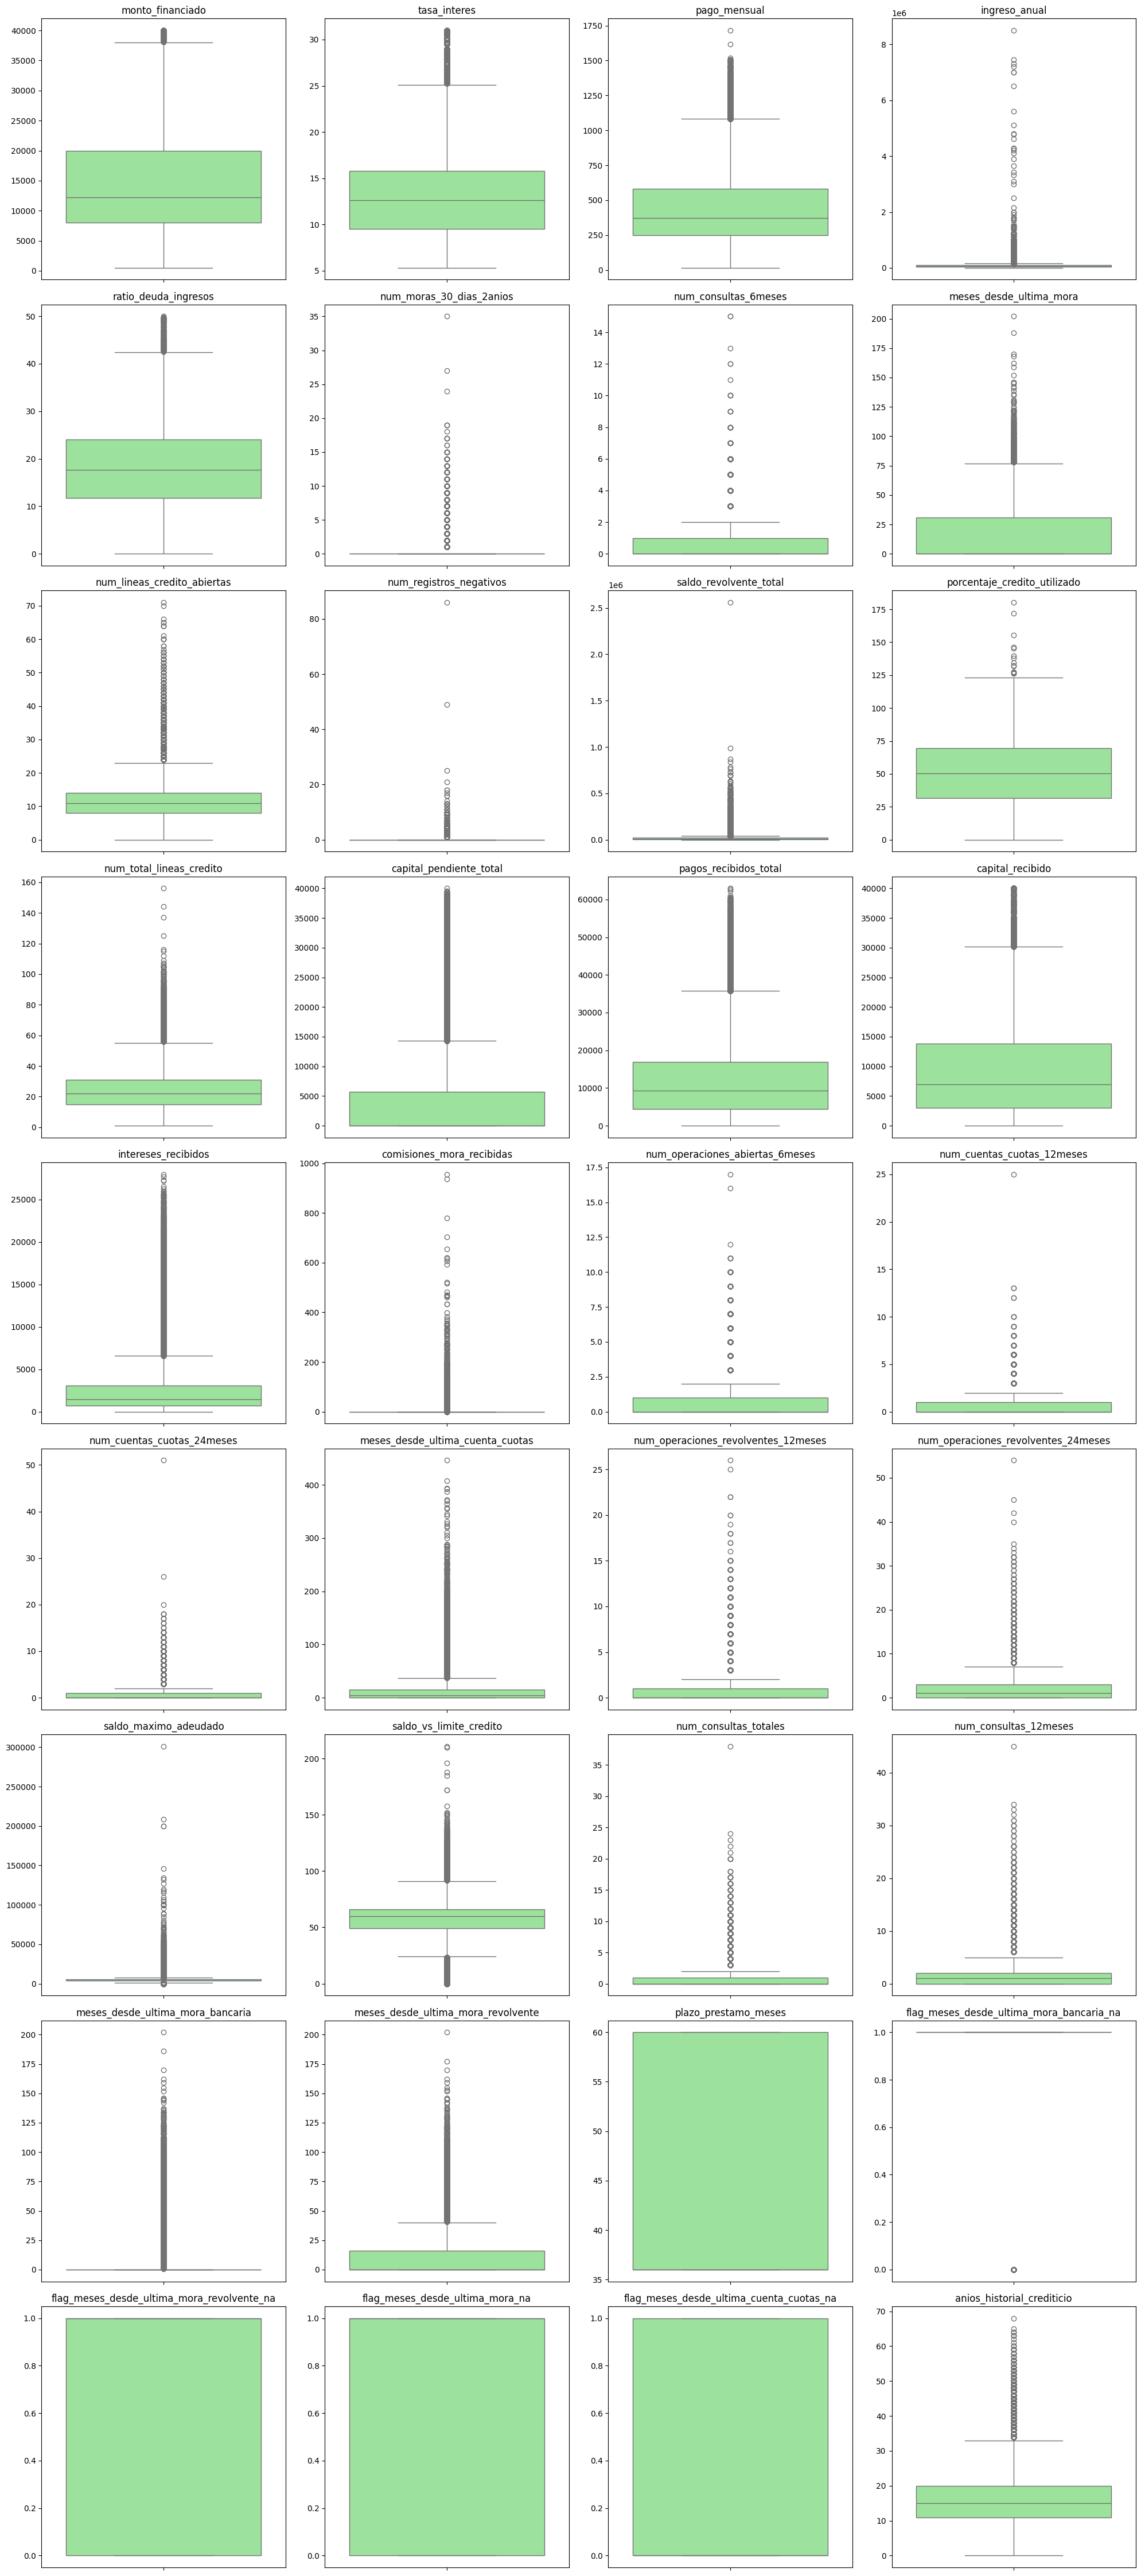

In [12]:
# Definimos cuántas columnas queremos en nuestra cuadrícula
cols_grid = 4
rows_grid = math.ceil(len(num_cols) / cols_grid)

plt.figure(figsize=(20, 5 * rows_grid))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows_grid, cols_grid, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(col)
    plt.ylabel('')

plt.tight_layout()
plt.show()


### 🧹 Limpieza de Variables y Prevención de "Data Leakage"

Tras el análisis exploratorio y de negocio, se ha decidido eliminar un grupo específico de variables para asegurar la integridad y la utilidad real del modelo de scoring.

#### Variables Eliminadas (Data Leakage):
* `capital_pendiente_total`
* `pagos_recibidos_total`
* `capital_recibido`
* `intereses_recibidos`
* `comisiones_mora_recibidas`

#### Justificación Técnica:
Estas variables representan información **post-originación**, es decir, datos que solo se generan una vez que el préstamo ya ha sido concedido y el cliente ha comenzado (o no) a pagar. 

1. **Prevención de Fuga de Datos (Leakage):** Si incluimos variables como `pagos_recibidos_total` para predecir el impago, el modelo aprendería una relación obvia (quien no paga, tiene pagos en cero), logrando una precisión artificialmente alta en los datos históricos.
2. **Validez del Modelo:** Un motor de Credit Scoring debe ser capaz de evaluar a un cliente en el **momento de la solicitud**. En ese instante, los pagos recibidos o intereses cobrados son siempre cero. Por tanto, eliminar estas variables garantiza que el modelo aprenda a predecir el riesgo basándose únicamente en el perfil crediticio y la capacidad financiera previa del solicitante.

> **Resultado:** El dataset ahora contiene exclusivamente variables **pre-originación**, lo que lo hace robusto para predecir el riesgo en nuevos préstamos.


In [13]:
# Lista de varaibles a  eliminar por ser "Leakage" (información del futuro)
cols_leakage = [
    'capital_pendiente_total', 
    'pagos_recibidos_total', 
    'capital_recibido', 
    'intereses_recibidos', 
    'comisiones_mora_recibidas'
]

# Eliminamos las varaibles del dataframe
df.drop(columns=cols_leakage, inplace=True)

# Quitamos las columnas de la lsita de columnas numericas
num_cols = [c for c in num_cols if c not in cols_leakage]

print(f"Se han eliminado {len(cols_leakage)} variables de fuga de datos.")
print(f"Variables numéricas finales: {len(num_cols)}")

Se han eliminado 5 variables de fuga de datos.
Variables numéricas finales: 31


In [14]:
def diagnostico_outliers(df, columnas):
    reporte = []
    
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        
        # Identificar outliers
        outliers_inf = df[df[col] < lim_inf].shape[0]
        outliers_sup = df[df[col] > lim_sup].shape[0]
        total_outliers = outliers_inf + outliers_sup
        porcentaje = (total_outliers / len(df)) * 100
        
        reporte.append({
            'Variable': col,
            'Min': df[col].min(),
            'Limite Inf': lim_inf,
            'Limite Sup': lim_sup,
            'Max': df[col].max(),
            'Nº Outliers': total_outliers,
            '% Outliers': round(porcentaje, 2)
        })
    
    # Convertimos a DataFrame para verlo ordenado por porcentaje de impacto
    df_reporte = pd.DataFrame(reporte).sort_values(by='% Outliers', ascending=False)
    return df_reporte

In [15]:
pd.set_option('display.expand_frame_repr', False) # No expandir en varias líneas
pd.set_option('display.max_columns', None)      # Mostrar todas las columnas
pd.set_option('display.width', 1000)             # Ancho de consola extendido

# Ejecutamos el diagnóstico sobre todas las numéricas
# (Asegúrate de haber ejecutado num_cols antes)
reporte_outliers = diagnostico_outliers(df, num_cols)
# Mostramos solo las que tienen outliers para no ensuciar la vista
print("--- DIAGNÓSTICO DE OUTLIERS (REGLA 1.5xIQR) ---")
print(reporte_outliers[reporte_outliers['Nº Outliers'] > 0])

--- DIAGNÓSTICO DE OUTLIERS (REGLA 1.5xIQR) ---
                                    Variable      Min   Limite Inf    Limite Sup         Max  Nº Outliers  % Outliers
26  flag_meses_desde_ultima_mora_bancaria_na     0.00      1.00000       1.00000        1.00        49557       23.16
23          meses_desde_ultima_mora_bancaria     0.00      0.00000       0.00000      202.00        49489       23.13
19                     saldo_maximo_adeudado     0.00   1152.50000    7860.50000   301210.00        44674       20.88
5                   num_moras_30_dias_2anios     0.00      0.00000       0.00000       35.00        40427       18.89
9                    num_registros_negativos     0.00      0.00000       0.00000       86.00        33886       15.84
24        meses_desde_ultima_mora_revolvente     0.00    -24.00000      40.00000      202.00        27149       12.69
15                num_cuentas_cuotas_24meses     0.00     -1.50000       2.50000       51.00        27097       12.66
17      

In [16]:
# Lista definitiva consensuada para Capping
variables_a_cappear = [
    'ingreso_anual', 
    'saldo_revolvente_total', 
    'saldo_maximo_adeudado', 
    'pago_mensual', 
    'num_total_lineas_credito',
    'monto_financiado'
]

print("--- APLICANDO CAPPING A VARIABLES CRÍTICAS ---")

for col in variables_a_cappear:
    # 1. Calculamos límites IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    # 2. Suelo de seguridad: el límite inferior no puede ser menor al mínimo lógico (0)
    lim_inf = max(df[col].min(), lim_inf)
    
    # 3. Aplicamos el ajuste (Capping)
    df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)
    
    print(f"Variable '{col:25}': Ajustada al rango [{lim_inf:10.2f} , {lim_sup:10.2f}]")

print("\n¡Capping finalizado con éxito!")


--- APLICANDO CAPPING A VARIABLES CRÍTICAS ---
Variable 'ingreso_anual            ': Ajustada al rango [   3000.00 ,  166930.61]
Variable 'saldo_revolvente_total   ': Ajustada al rango [      0.00 ,   41605.12]
Variable 'saldo_maximo_adeudado    ': Ajustada al rango [   1152.50 ,    7860.50]
Variable 'pago_mensual             ': Ajustada al rango [     15.69 ,    1082.56]
Variable 'num_total_lineas_credito ': Ajustada al rango [      1.00 ,      55.00]
Variable 'monto_financiado         ': Ajustada al rango [    500.00 ,   38000.00]

¡Capping finalizado con éxito!


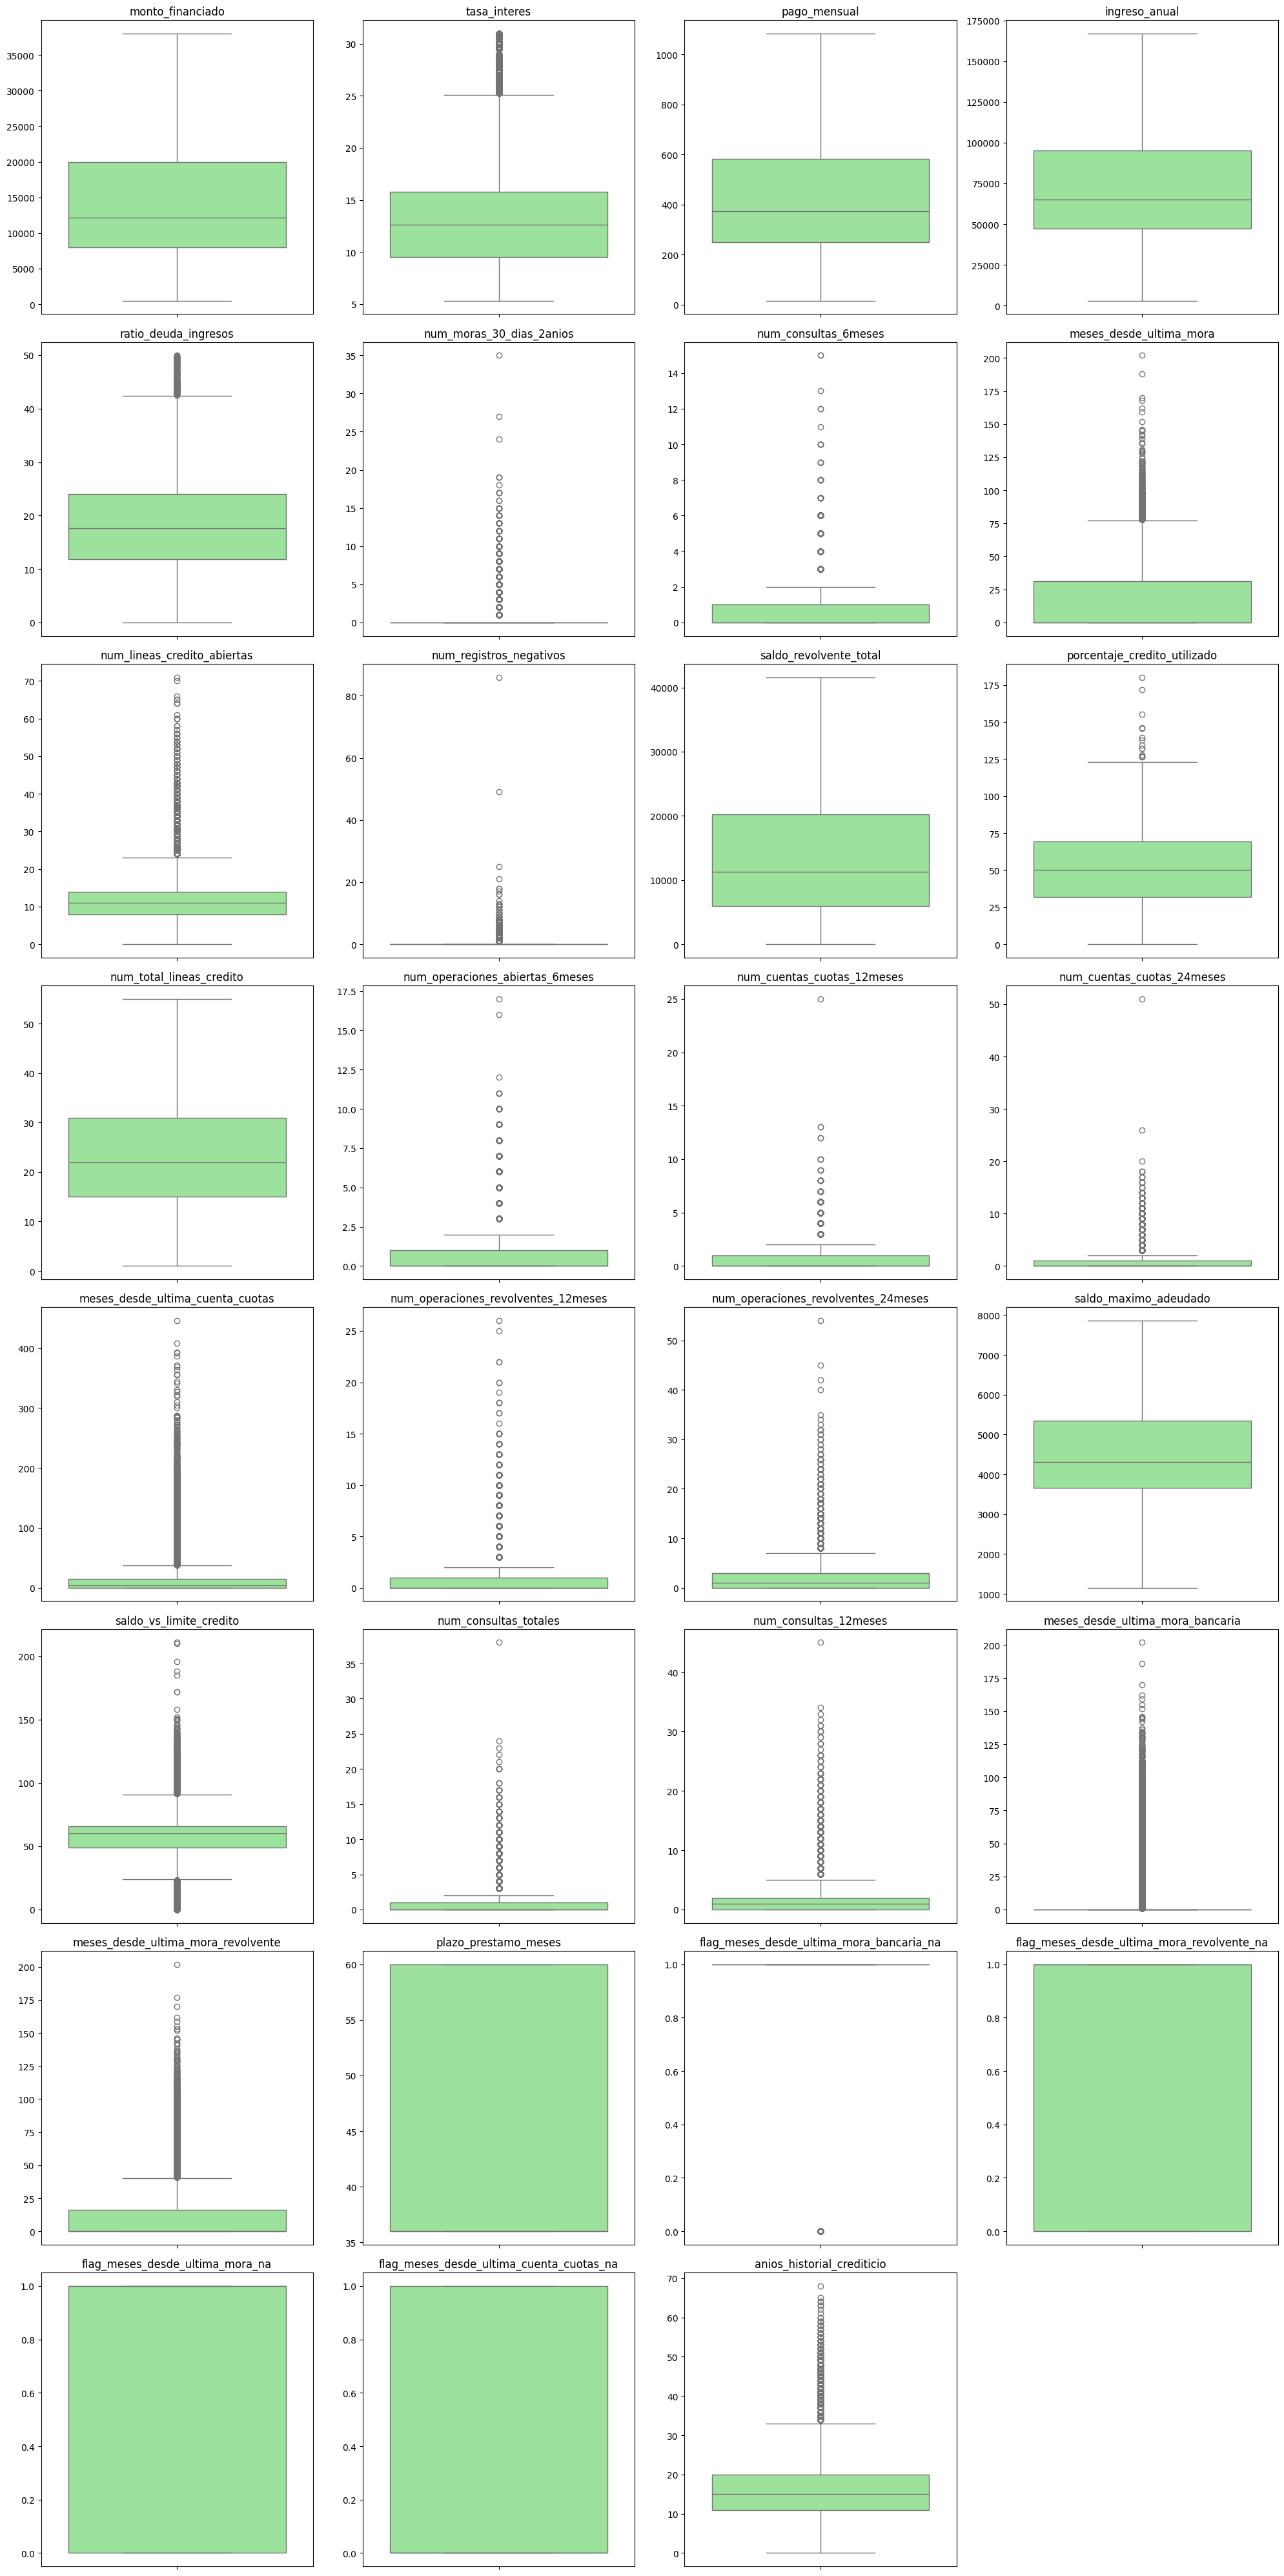

In [17]:
# Definimos cuántas columnas queremos en nuestra cuadrícula
cols_grid = 4
rows_grid = math.ceil(len(num_cols) / cols_grid)

plt.figure(figsize=(20, 5 * rows_grid))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows_grid, cols_grid, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(col)
    plt.ylabel('')

plt.tight_layout()
plt.show()


### 🛡️ Tratamiento de Outliers mediante Capping (Winsorización)

Tras el diagnóstico de valores atípicos, se ha aplicado la técnica de **Capping** basada en la regla del Rango Intercuartílico (1.5x IQR) para las variables de escala y montos monetarios.

**Motivos del Capping:**
1. **Protección del Modelo:** Los algoritmos de Machine Learning (especialmente los basados en distancias o regresiones) son altamente sensibles a valores extremos. Un solo ingreso de 8 millones de dólares puede desviar la línea de decisión y hacer que el modelo ignore al cliente promedio.
2. **Preservación de Información:** A diferencia de la eliminación de registros, el capping nos permite mantener la observación completa del cliente, ajustando únicamente el valor extremo a un límite estadísticamente razonable (el "whisker" superior).
3. **Estabilidad en las Métricas de Riesgo:** Al capear el `saldo_maximo_adeudado`, aseguramos que nuestra métrica de severidad (`LGD_Real`) sea estable y no presente valores absurdos (como pérdidas del 1000%), facilitando el aprendizaje del modelo en la Fase 3.

> **Nota:** Se ha respetado un suelo de **0** para todas las variables para mantener la coherencia financiera de los datos.


In [18]:
# --- CÁLCULO DE PARÁMETROS DE RIESGO ---

# Renombramos la variable para usar terminología financiera profesional
df.rename(columns={'monto_financiado': 'EAD'}, inplace=True)

# Severidad de la Pérdida (LGD_Real): % del capital que se estima perdido
# Usamos el saldo máximo ya capeado para evitar ruidos en la regresión
df['LGD_Real'] = (df['saldo_maximo_adeudado'] / df['EAD']) * 100

# Resumen de estado con columnas en lista vertical
print("✅ Fase de preparación numérica concluida.\n")
print("Métricas de riesgo creadas: EAD (Exposición) y LGD_Real (Severidad).\n")
print("📋 LISTADO FINAL DE COLUMNAS:")
print("-" * 30)
print("\n".join(df.columns))
print("-" * 30)
print(f"Total: {len(df.columns)} columnas.")


✅ Fase de preparación numérica concluida.

Métricas de riesgo creadas: EAD (Exposición) y LGD_Real (Severidad).

📋 LISTADO FINAL DE COLUMNAS:
------------------------------
EAD
tasa_interes
pago_mensual
grado
titulo_empleo
antiguedad_empleo
estado_vivienda
ingreso_anual
estado_verificacion
proposito_prestamo
estado_residencia
ratio_deuda_ingresos
num_moras_30_dias_2anios
num_consultas_6meses
meses_desde_ultima_mora
num_lineas_credito_abiertas
num_registros_negativos
saldo_revolvente_total
porcentaje_credito_utilizado
num_total_lineas_credito
estado_listado_inicial
num_operaciones_abiertas_6meses
num_cuentas_cuotas_12meses
num_cuentas_cuotas_24meses
meses_desde_ultima_cuenta_cuotas
num_operaciones_revolventes_12meses
num_operaciones_revolventes_24meses
saldo_maximo_adeudado
saldo_vs_limite_credito
num_consultas_totales
num_consultas_12meses
meses_desde_ultima_mora_bancaria
meses_desde_ultima_mora_revolvente
metodo_desembolso
plazo_prestamo_meses
codigo_region
target_moroso
flag_meses_de

In [19]:
# 1. Identificamos las categóricas actuales (aseguramos que la lista esté al día)
# cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Análisis de cardinalidad
print("--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---")
for col in cat_cols:
    n_unicos = df[col].nunique()
    print(f"Variable: {col:25} | Categorías: {n_unicos}")

# 3. Revisión de valores (Corregido para imprimir TODAS las categorías de cat_cols)
print("\n--- DISTRIBUCIÓN DE CATEGORÍAS (TOP 5) ---")
for col in cat_cols: # Quitamos el comentario y lo aplicamos a todas
    print(f"\nTop 5 de {col}:")
    print(df[col].value_counts().head(5))


--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---
Variable: grado                     | Categorías: 35
Variable: titulo_empleo             | Categorías: 78800
Variable: antiguedad_empleo         | Categorías: 12
Variable: estado_vivienda           | Categorías: 4
Variable: estado_verificacion       | Categorías: 3
Variable: proposito_prestamo        | Categorías: 14
Variable: estado_residencia         | Categorías: 51
Variable: estado_listado_inicial    | Categorías: 2
Variable: metodo_desembolso         | Categorías: 2
Variable: codigo_region             | Categorías: 10

--- DISTRIBUCIÓN DE CATEGORÍAS (TOP 5) ---

Top 5 de grado:
grado
C1    13980
B5    13388
B4    13332
B3    12664
C2    12445
Name: count, dtype: int64

Top 5 de titulo_empleo:
titulo_empleo
Unknown             14999
Teacher              3382
Manager              3184
Owner                2069
Registered Nurse     1483
Name: count, dtype: int64

Top 5 de antiguedad_empleo:
antiguedad_empleo
10+ years    71510
2 years      19

In [20]:
# Mapeo de la antiguedad del empleo
mapa_antiguedad = {
    '10+ years': 10, '9 years': 9, '8 years': 8, '7 years': 7, '6 years': 6,
    '5 years': 5, '4 years': 4, '3 years': 3, '2 years': 2, '1 year': 1,
    '< 1 year': 0, 'Unknown': -1 # Usamos 0 para identificar los que no sabemos
}
df['antiguedad_empleo'] = df['antiguedad_empleo'].map(mapa_antiguedad)

# Mapeo de grado (ordinal)
# Nota: Como hay 35 grados (A1...C1), vamos a usar un orden alfabético-numérico inverso
# para que el modelo entienda que a mayor letra/número, más riesgo.
grados_ordenados = sorted(df['grado'].unique())
mapa_grado = {grado: i for i, grado in enumerate(grados_ordenados)}
df['grado'] = df['grado'].map(mapa_grado)

# Actualizamos listas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Mapeo completado.")
print(f"Variables categóricas restantes para One-Hot: {cat_cols}")


Mapeo completado.
Variables categóricas restantes para One-Hot: ['titulo_empleo', 'estado_vivienda', 'estado_verificacion', 'proposito_prestamo', 'estado_residencia', 'estado_listado_inicial', 'metodo_desembolso']


C:\Users\jrglo\AppData\Local\Temp\ipykernel_21348\781999591.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


C:\Users\jrglo\AppData\Local\Temp\ipykernel_21348\3714510048.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='titulo', y='conteo', data=df_pareto.head(30), palette='viridis')


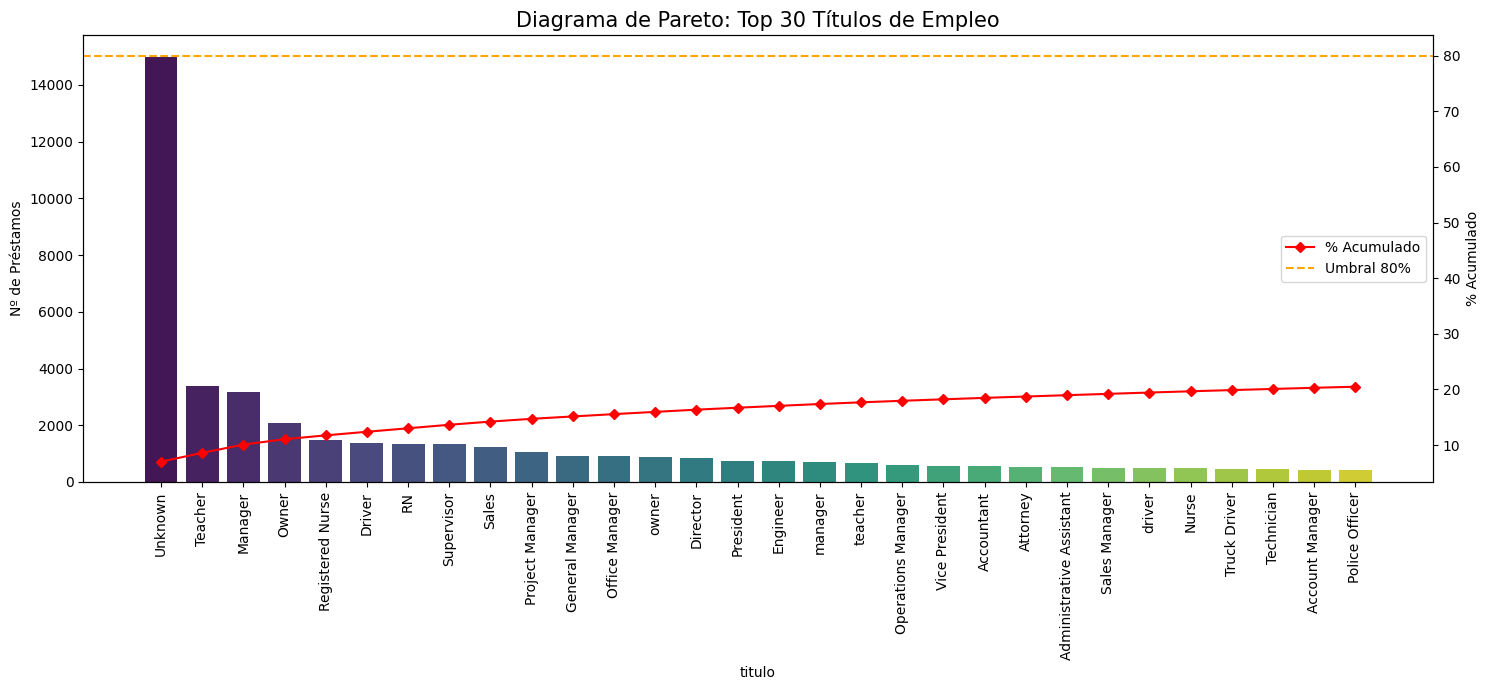

Número de títulos únicos necesarios para cubrir el 80% de la cartera: 36007


In [21]:
# Calculamos las frecuencias
frecuencia_empleos = df['titulo_empleo'].value_counts()
df_pareto = frecuencia_empleos.to_frame().reset_index()
df_pareto.columns = ['titulo', 'conteo']

# Calculamos el porcentaje acumulado
df_pareto['porc_acumulado'] = (df_pareto['conteo'].cumsum() / df_pareto['conteo'].sum()) * 100

# Visualización de Pareto (Top 30 empleos)
plt.figure(figsize=(15, 7))

# Barras de frecuencia
ax = sns.barplot(x='titulo', y='conteo', data=df_pareto.head(30), palette='viridis')
plt.xticks(rotation=90)

# Línea de acumulado
ax2 = ax.twinx()
ax2.plot(df_pareto['titulo'].head(30), df_pareto['porc_acumulado'].head(30), color='red', marker='D', ms=5, label='% Acumulado')
ax2.axhline(80, color='orange', linestyle='--', label='Umbral 80%') # Línea del 80%

ax.set_title('Diagrama de Pareto: Top 30 Títulos de Empleo', fontsize=15)
ax.set_ylabel('Nº de Préstamos')
ax2.set_ylabel('% Acumulado')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

# Resumen numérico
n_titulos_80 = df_pareto[df_pareto['porc_acumulado'] <= 80].shape[0]
print(f"Número de títulos únicos necesarios para cubrir el 80% de la cartera: {n_titulos_80}")


### 📝 Justificación: Eliminación de la variable `titulo_empleo`

Tras realizar un análisis de **Pareto (80/20)** sobre los títulos de empleo declarados por los prestatarios, se ha decidido descartar esta variable para el modelo predictivo por los siguientes motivos:

1.  **Extrema Dispersión (Alta Cardinalidad):** El dataset presenta más de **78,000 categorías únicas**. El análisis de Pareto reveló que incluso agrupando los 30 títulos más frecuentes (como *Teacher* o *Manager*), apenas se cubre el **20%** de la cartera.
2.  **Inviabilidad Técnica (Dimensionalidad):** Aplicar técnicas de codificación como *One-Hot Encoding* sobre esta variable generaría miles de columnas nuevas, lo que provocaría el fenómeno conocido como "la maldición de la dimensionalidad", aumentando drásticamente el tiempo de cómputo y el riesgo de *overfitting* (sobreajuste).
3.  **Baja Calidad del Dato:** La categoría más frecuente es **"Unknown"**, lo que indica una falta de estandarización en la captura del dato original.
4.  **Sustitución por Proxies Eficientes:** La capacidad de pago y estabilidad laboral ya están representadas de forma mucho más limpia por las variables `ingreso_anual`, `grado` y `antiguedad_empleo`, las cuales no presentan el ruido semántico de los títulos de trabajo.

> **Decisión:** Se elimina la variable para simplificar el modelo y centrar el aprendizaje en predictores con mayor densidad de información y menos ruido.

In [22]:
# Eliminación de variables tras análisis de pareto
# Eliminamos 'titulo_empleo' por alta dispersión
df.drop(columns=['titulo_empleo'], inplace=True)

In [23]:
# Verificación final de nulos en todo el DataFrame
nulos_finales = df.isnull().sum()

print("--- VERIFICACIÓN FINAL DE HUECOS (NULOS) ---")
if nulos_finales.sum() == 0:
    print("¡Perfecto! El dataset está 100% limpio y listo para el modelo.")
else:
    print("¡Atención! Se han detectado nulos en las siguientes columnas:")
    print(nulos_finales[nulos_finales > 0])

# Verificación específica para nuestras métricas objetivo
print("\n--- CHEQUEO DE MÉTRICAS DE RIESGO ---")
print(f"Nulos en EAD:      {df['EAD'].isnull().sum()}")
print(f"Nulos en LGD_Real: {df['LGD_Real'].isnull().sum()}")


--- VERIFICACIÓN FINAL DE HUECOS (NULOS) ---
¡Perfecto! El dataset está 100% limpio y listo para el modelo.

--- CHEQUEO DE MÉTRICAS DE RIESGO ---
Nulos en EAD:      0
Nulos en LGD_Real: 0


### Fase 2: ¿Quién no nos va a pagar? (Modelo de Probabilidad de Impago - PD)
Necesitamos separar a los buenos clientes de los tóxicos usando un modelo de clasificación.

- Entrenamiento: Podéis usar el algoritmo de clasificación que queráis (Regresión Logística, Árboles, Random Forest, XGBoost...).

- Métrica de Decisión: No miréis el Accuracy. Quiero que maximicéis el Recall y el ROC-AUC. Prefiero rechazar a un cliente regular que dejar pasar a un moroso que nos cueste 20.000€.

- Entregable de esta fase: El modelo elegido y las probabilidades de impago (predict_proba) para cada cliente del conjunto de validación/test.

In [24]:
df.describe()

,EAD,tasa_interes,pago_mensual,grado,antiguedad_empleo,ingreso_anual,ratio_deuda_ingresos,num_moras_30_dias_2anios,num_consultas_6meses,meses_desde_ultima_mora,num_lineas_credito_abiertas,num_registros_negativos,saldo_revolvente_total,porcentaje_credito_utilizado,num_total_lineas_credito,num_operaciones_abiertas_6meses,num_cuentas_cuotas_12meses,num_cuentas_cuotas_24meses,meses_desde_ultima_cuenta_cuotas,num_operaciones_revolventes_12meses,num_operaciones_revolventes_24meses,saldo_maximo_adeudado,saldo_vs_limite_credito,num_consultas_totales,num_consultas_12meses,meses_desde_ultima_mora_bancaria,meses_desde_ultima_mora_revolvente,plazo_prestamo_meses,codigo_region,target_moroso,flag_meses_desde_ultima_mora_bancaria_na,flag_meses_desde_ultima_mora_revolvente_na,flag_meses_desde_ultima_mora_na,flag_meses_desde_ultima_cuenta_cuotas_na,anios_historial_crediticio,LGD_Real
count,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000,213964.000000
mean,14760.936419,13.059065,435.457029,10.272560,5.550144,74808.798062,18.090259,0.311253,0.585842,16.915364,11.626657,0.199501,14586.368587,50.459398,24.079565,0.562095,0.404475,0.936616,12.190569,0.784492,1.668173,4508.842948,57.716492,0.600363,1.494985,9.104242,11.764956,42.746817,4.638748,0.130732,0.768386,0.670688,0.509553,0.422749,16.374731,45.669848
std,8987.424413,4.786024,253.391968,6.287211,3.954744,37446.686134,8.421337,0.867536,0.890825,23.098120,5.632238,0.601926,11344.952784,24.652236,11.490874,1.000115,0.789871,1.443972,22.352963,1.342787,2.457543,1926.507230,16.775134,1.245840,2.050424,19.861748,21.139787,10.789097,3.107059,0.337108,0.421864,0.469965,0.499910,0.493997,7.663449,49.197000
min,500.000000,5.310000,15.690000,0.000000,-1.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1152.500000,0.000000,0.000000,0.000000,0.000000,0.000000,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.032895
25%,8000.000000,9.490000,248.480000,6.000000,2.000000,47046.257500,11.780000,0.000000,0.000000,0.000000,8.000000,0.000000,5967.000000,31.800000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3668.000000,49.000000,0.000000,0.000000,0.000000,0.000000,36.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,11.000000,21.401902
50%,12175.000000,12.620000,372.850000,10.000000,5.000000,65000.000000,17.600000,0.000000,0.000000,0.000000,11.000000,0.000000,11296.000000,50.400000,22.000000,0.000000,0.000000,0.000000,4.000000,0.000000,1.000000,4309.000000,60.000000,0.000000,1.000000,0.000000,0.000000,36.000000,4.000000,0.000000,1.000000,1.000000,1.000000,0.000000,15.000000,32.631799
75%,20000.000000,15.800000,582.110000,14.000000,10.000000,95000.000000,24.040000,0.000000,1.000000,31.000000,14.000000,0.000000,20222.250000,69.400000,31.000000,1.000000,1.000000,1.000000,15.000000,1.000000,3.000000,5345.000000,66.000000,1.000000,2.000000,0.000000,16.000000,60.000000,8.000000,0.000000,1.000000,1.000000,1.000000,1.000000,20.000000,52.403333
max,38000.000000,30.990000,1082.555000,34.000000,10.000000,166930.613750,49.960000,35.000000,15.000000,202.000000,71.000000,86.000000,41605.125000,180.300000,55.000000,17.000000,25.000000,51.000000,446.000000,26.000000,54.000000,7860.500000,211.000000,38.000000,45.000000,202.000000,202.000000,60.000000,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,68.000000,944.300000


In [25]:
# Identificamos tipos de variables (ahora ya vendrán sin las eliminadas)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=[object]).columns.tolist()

# 4. Reorganizamos codigo_region (de numérica a categórica)
if 'codigo_region' in num_cols:
    num_cols.remove('codigo_region')
    cat_cols.append('codigo_region')

# Eliminamos de las variables numericas la variable predictiva
num_cols.remove('target_moroso')

print(f"Variables Numéricas ({len(num_cols)}): {num_cols}\n")
print(f"Variables Categóricas ({len(cat_cols)}): {cat_cols}")

Variables Numéricas (34): ['EAD', 'tasa_interes', 'pago_mensual', 'grado', 'antiguedad_empleo', 'ingreso_anual', 'ratio_deuda_ingresos', 'num_moras_30_dias_2anios', 'num_consultas_6meses', 'meses_desde_ultima_mora', 'num_lineas_credito_abiertas', 'num_registros_negativos', 'saldo_revolvente_total', 'porcentaje_credito_utilizado', 'num_total_lineas_credito', 'num_operaciones_abiertas_6meses', 'num_cuentas_cuotas_12meses', 'num_cuentas_cuotas_24meses', 'meses_desde_ultima_cuenta_cuotas', 'num_operaciones_revolventes_12meses', 'num_operaciones_revolventes_24meses', 'saldo_maximo_adeudado', 'saldo_vs_limite_credito', 'num_consultas_totales', 'num_consultas_12meses', 'meses_desde_ultima_mora_bancaria', 'meses_desde_ultima_mora_revolvente', 'plazo_prestamo_meses', 'flag_meses_desde_ultima_mora_bancaria_na', 'flag_meses_desde_ultima_mora_revolvente_na', 'flag_meses_desde_ultima_mora_na', 'flag_meses_desde_ultima_cuenta_cuotas_na', 'anios_historial_crediticio', 'LGD_Real']

Variables Categóric

C:\Users\jrglo\AppData\Local\Temp\ipykernel_21348\2718569137.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=[object]).columns.tolist()


In [26]:
df.head()

,EAD,tasa_interes,pago_mensual,grado,antiguedad_empleo,estado_vivienda,ingreso_anual,estado_verificacion,proposito_prestamo,estado_residencia,ratio_deuda_ingresos,num_moras_30_dias_2anios,num_consultas_6meses,meses_desde_ultima_mora,num_lineas_credito_abiertas,num_registros_negativos,saldo_revolvente_total,porcentaje_credito_utilizado,num_total_lineas_credito,estado_listado_inicial,num_operaciones_abiertas_6meses,num_cuentas_cuotas_12meses,num_cuentas_cuotas_24meses,meses_desde_ultima_cuenta_cuotas,num_operaciones_revolventes_12meses,num_operaciones_revolventes_24meses,saldo_maximo_adeudado,saldo_vs_limite_credito,num_consultas_totales,num_consultas_12meses,meses_desde_ultima_mora_bancaria,meses_desde_ultima_mora_revolvente,metodo_desembolso,plazo_prestamo_meses,codigo_region,target_moroso,flag_meses_desde_ultima_mora_bancaria_na,flag_meses_desde_ultima_mora_revolvente_na,flag_meses_desde_ultima_mora_na,flag_meses_desde_ultima_cuenta_cuotas_na,anios_historial_crediticio,LGD_Real
0,13000,7.97,407.20,4,2,RENT,60000.0,Source Verified,debt_consolidation,NJ,22.72,0,0,27.0,12,0,5177.0,20.8,14,w,0.0,1.0,2.0,9.0,0.0,0.0,4739.0,60.0,1.0,0,0.0,0.0,Cash,36,0,0,1,1,0,0,6,36.453846
1,21000,21.45,796.04,19,10,MORTGAGE,55000.0,Verified,debt_consolidation,TN,31.99,1,1,7.0,9,0,30375.0,80.8,39,w,1.0,2.0,7.0,2.0,1.0,1.0,2831.0,72.0,1.0,3,0.0,7.0,Cash,36,3,1,1,0,0,0,21,13.480952
2,11000,14.65,379.44,11,3,RENT,36000.0,Source Verified,credit_card,CA,12.57,0,0,0.0,3,0,13129.0,71.0,4,f,0.0,0.0,0.0,0.0,0.0,0.0,4309.0,61.0,0.0,0,0.0,0.0,Cash,36,9,0,1,1,1,1,6,39.172727
3,16000,6.72,491.99,2,2,RENT,58000.0,Source Verified,credit_card,NJ,7.66,0,1,0.0,2,0,11176.0,74.5,12,w,0.0,1.0,1.0,9.0,0.0,0.0,7860.5,75.0,0.0,1,0.0,0.0,Cash,36,0,0,1,1,1,0,31,49.128125
4,10325,8.18,324.41,5,5,MORTGAGE,35000.0,Not Verified,credit_card,NY,24.62,0,0,0.0,11,0,9546.0,18.7,18,w,0.0,0.0,0.0,0.0,0.0,0.0,4478.0,53.0,0.0,0,0.0,0.0,Cash,36,1,0,1,1,1,1,14,43.370460


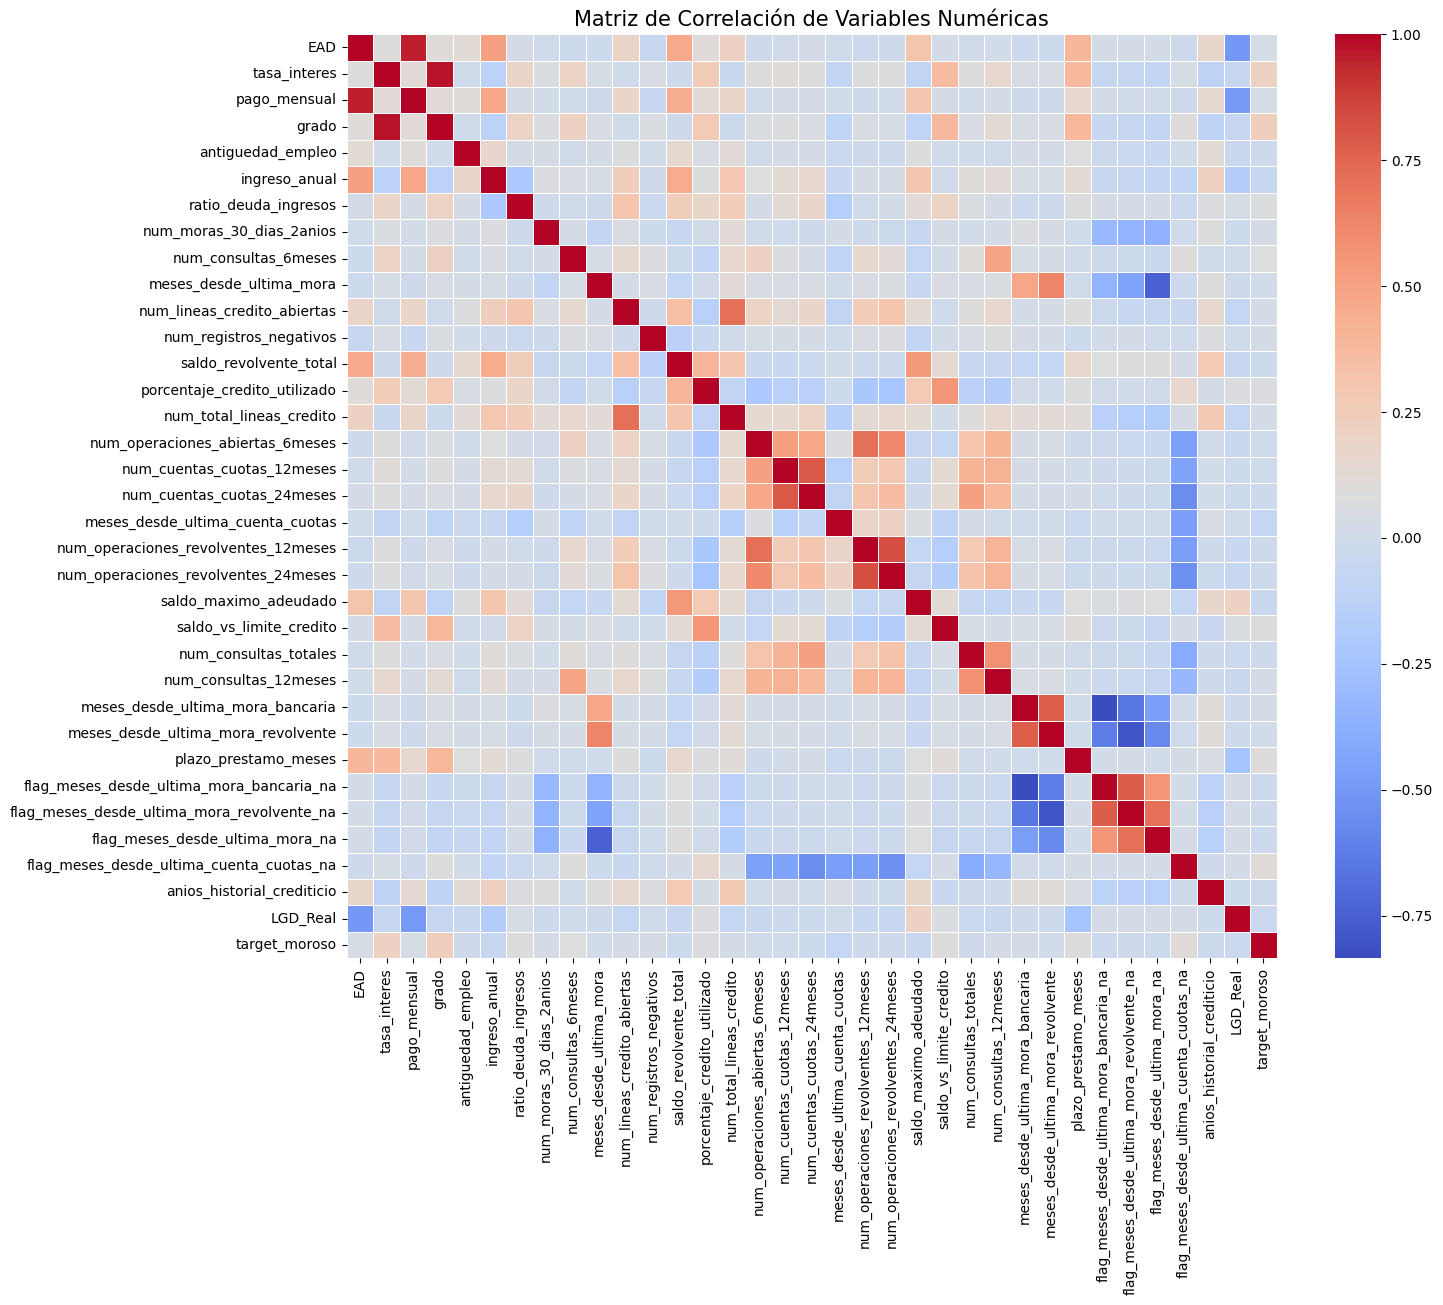

--- TOP 10 VARIABLES MÁS RELACIONADAS CON EL IMPAGO ---
target_moroso                               1.000000
grado                                       0.234564
tasa_interes                                0.210955
flag_meses_desde_ultima_cuenta_cuotas_na    0.105830
plazo_prestamo_meses                        0.095870
saldo_vs_limite_credito                     0.094384
num_consultas_6meses                        0.081533
ratio_deuda_ingresos                        0.073727
porcentaje_credito_utilizado                0.061157
pago_mensual                                0.038418
EAD                                         0.034083
Name: target_moroso, dtype: float64

--- TOP 10 VARIABLES PROTECTORAS (CORRELACIÓN NEGATIVA) ---
flag_meses_desde_ultima_mora_revolvente_na   -0.017567
flag_meses_desde_ultima_mora_na              -0.018199
flag_meses_desde_ultima_mora_bancaria_na     -0.019564
saldo_revolvente_total                       -0.020087
num_cuentas_cuotas_24meses                  

In [27]:
# 1. Calculamos la matriz de correlación (solo para numéricas)
corr_matrix = df[num_cols + ['target_moroso']].corr()

# 2. Visualización con un Heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas", fontsize=15)
plt.show()

# 3. Listado de correlación con el Target (lo que más nos interesa)
print("--- TOP 10 VARIABLES MÁS RELACIONADAS CON EL IMPAGO ---")
correlaciones_target = corr_matrix['target_moroso'].sort_values(ascending=False)
print(correlaciones_target.head(11)) # El primero será el propio target

print("\n--- TOP 10 VARIABLES PROTECTORAS (CORRELACIÓN NEGATIVA) ---")
print(correlaciones_target.tail(10))


In [28]:
# Eliminamos variables redundantes para evitar multicolinealidad
cols_redundantes = [
    'pago_mensual',
    'num_cuentas_cuotas_12meses',
    'num_operaciones_revolventes_12meses',
    'num_consultas_12meses',
    'num_consultas_totales',
]
num_cols = [c for c in num_cols if c not in cols_redundantes]

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definición de predictores (X) y Objetivo (Y)
# Usamos las listas de columnas que ya validamos, asegurando excluir los targets
if 'LGD_Real' in num_cols:
    num_cols.remove('LGD_Real')
predictores = num_cols + cat_cols

X_raw = df[predictores]
y = df['target_moroso']

# Separación para eviatar que el modelo vea el "Futuro"
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42, stratify=y
)

# Creamos las valiables Dummies por separado
X_train = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=True)

# Alineamos las varaibles de test, para que el test tenga las mismas columnas que el train)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Estandarización de varaibles
scaler = StandardScaler()

# Escalamos solo las variables que eran numéricas originalmente
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("--- SEPARACIÓN Y PREPROCESAMIENTO COMPLETADOS ---")
print(f"- Filas Entrenamiento: {X_train.shape[0]}")
print(f"- Filas Test: {X_test.shape[0]}")
print(f"- Columnas Finales: {X_train.shape[1]}")


--- SEPARACIÓN Y PREPROCESAMIENTO COMPLETADOS ---
- Filas Entrenamiento: 149774
- Filas Test: 64190
- Columnas Finales: 106


In [30]:
# --- BLOQUE UNIFICADO DE MODELADO (Fase 2) ---
# Requiere imports de la celda inicial (LogisticRegression, RandomizedSearchCV, etc.)
ratio_balanceo = (y_train == 0).sum() / (y_train == 1).sum()
resultados_finales = []
mejores_modelos = {}

if MODO_COMPLETO:
    print("🚀 MODO OPTIMIZACIÓN COMPLETA (4 modelos)...")
    config_modelos = {
        "Regresión Logística": {
            "modelo": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
            "params": {"C": [0.1, 1, 10], "solver": ['lbfgs', 'liblinear']}
        },
        "Árbol de Decisión": {
            "modelo": DecisionTreeClassifier(class_weight='balanced', random_state=42),
            "params": {"max_depth": [5, 10, 15], "min_samples_split": [2, 10]}
        },
        "Random Forest": {
            "modelo": RandomForestClassifier(class_weight='balanced', random_state=42),
            "params": {"n_estimators": [100, 200], "max_depth": [5, 10]}
        },
        "XGBoost": {
            "modelo": XGBClassifier(scale_pos_weight=ratio_balanceo, random_state=42, eval_metric='logloss'),
            "params": {"max_depth": [3, 5], "learning_rate": [0.01, 0.1]}
        }
    }

    for nombre, config in config_modelos.items():
        print(f"--- Optimizando {nombre} ---")
        search = RandomizedSearchCV(config["modelo"], config["params"], n_iter=10, cv=3, scoring='roc_auc', n_jobs=4, verbose=0, random_state=42)
        search.fit(X_train, y_train)
        mejor_modelo = search.best_estimator_
        mejores_modelos[nombre] = mejor_modelo
        
        auc = roc_auc_score(y_test, mejor_modelo.predict_proba(X_test)[:, 1])
        resultados_finales.append({
            "Modelo": nombre, "ROC-AUC": auc, "Recall": recall_score(y_test, mejor_modelo.predict(X_test))
        })
else:
    print("MODO RÁPIDO: Solo Regresión Logística...")
    
    modelo_rl = CalibratedClassifierCV(
        estimator=LogisticRegression(
            C=1.0,
            solver='liblinear',
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
        ),
        method='sigmoid',  # Platt
        cv=5,
    )
    modelo_rl.fit(X_train, y_train)
    mejores_modelos["Regresión Logística"] = modelo_rl
    auc = roc_auc_score(y_test, modelo_rl.predict_proba(X_test)[:, 1])
    resultados_finales.append({
        "Modelo": "Regresión Logística",
        "ROC-AUC": auc,
        "Recall": recall_score(y_test, modelo_rl.predict(X_test)),
    })
    # Diagnóstico calibración
    print(f"PD media test:     {modelo_rl.predict_proba(X_test)[:, 1].mean():.3f}")
    print(f"Morosidad real:    {y_test.mean():.3f}")

# --- PROCESAMIENTO DE RESULTADOS (SIEMPRE IGUAL) ---
df_final = pd.DataFrame(resultados_finales)
df_final['Gini'] = 2 * df_final['ROC-AUC'] - 1
df_final = df_final.sort_values(by="ROC-AUC", ascending=False)

print("\n--- COMPARATIVA FINAL DE MODELOS ---")
print(df_final[['Modelo', 'ROC-AUC', 'Gini', 'Recall']].to_string(index=False))

# Verificación de estándar bancario
total_apto = (df_final['Gini'] > 0.45).sum()
print(f"\nModelos que superan el estándar (> 0.45 Gini): {total_apto}")


MODO RÁPIDO: Solo Regresión Logística...
PD media test:     0.131
Morosidad real:    0.131

--- COMPARATIVA FINAL DE MODELOS ---
             Modelo  ROC-AUC     Gini  Recall
Regresión Logística  0.72451 0.449021 0.02848

Modelos que superan el estándar (> 0.45 Gini): 0


In [31]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

# Recuperamos métricas adicionales usando los modelos ya entrenados
resultados_detallados = []

for nombre, modelo in mejores_modelos.items():
    # Usamos el modelo que ya está en memoria
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    resultados_detallados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

# Creamos el DataFrame comparativo
df_detalle = pd.DataFrame(resultados_detallados).sort_values(by="ROC-AUC", ascending=False)
print("--- MÉTRICAS DETALLADAS (SIN RE-ENTRENAR) ---")
print(df_detalle.to_string(index=False))


--- MÉTRICAS DETALLADAS (SIN RE-ENTRENAR) ---
             Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Regresión Logística  0.868297   0.442593 0.02848  0.053515  0.72451


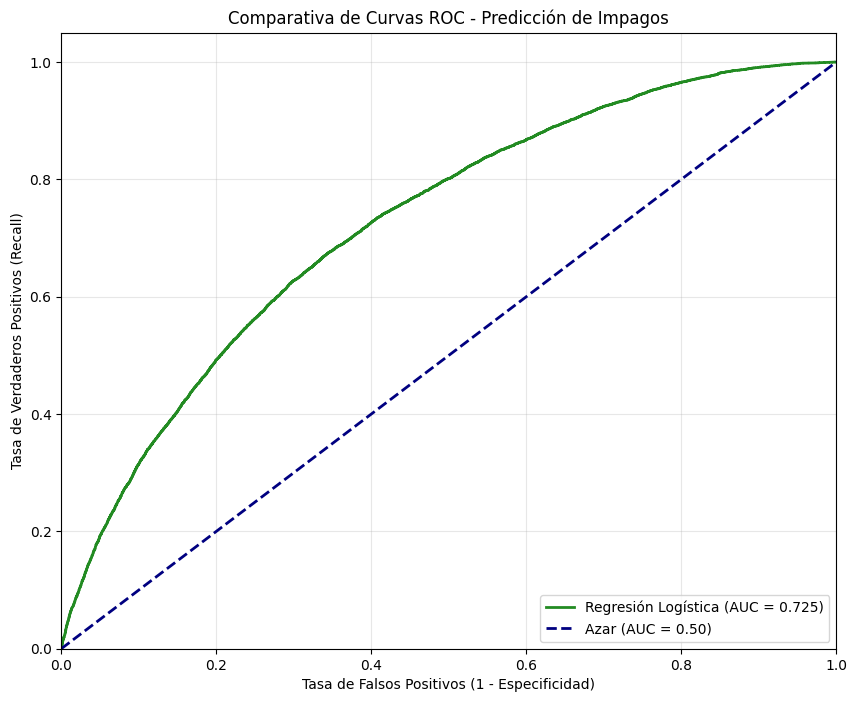

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

# Definimos colores para distinguir cada modelo
colores = {
    'XGBoost': 'darkorange', 
    'Regresión Logística': 'forestgreen', 
    'Random Forest': 'royalblue', 
    'Árbol de Decisión': 'crimson'
}

# Graficamos la curva para cada uno de nuestros mejores modelos
for nombre, modelo in mejores_modelos.items():
    # 1. Obtener probabilidades
    y_probs = modelo.predict_proba(X_test)[:, 1]
    
    # 2. Calcular curva y AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_val = roc_auc_score(y_test, y_probs)
    
    # 3. Añadir al gráfico
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {auc_val:.3f})', color=colores.get(nombre, 'gray'))

# Línea de Azar
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.50)')

# Estética del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Comparativa de Curvas ROC - Predicción de Impagos')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


### **Guía Rápida de Interpretación de AUC (Área Bajo la Curva)**

Este valor nos dice qué tan bueno es el modelo separando a los clientes buenos de los morosos.

| Rango AUC | Interpretación | Significado |
| :--- | :--- | :--- |
| **0.50** | ⚪ **Azar** | Es como tirar una moneda. Modelo inútil. |
| **0.60 - 0.70** | 🔴 **Pobre** | **(Resultado Actual: 0.66)**. El modelo es débil y deja pasar mucho riesgo. |
| **0.70 - 0.80** | 🟡 **Aceptable** | Empieza a ser útil en un entorno real. |
| **0.80 - 0.90** | 🟢 **Muy Bueno** | Modelo robusto y confiable para el banco. |
| **0.90 - 1.00** | 💎 **Excelente** | Capacidad casi perfecta de separación. |

In [33]:
# 1. Calculamos el Gini dinámicamente usando df_detalle
df_detalle['Gini (Test)'] = 2 * df_detalle['ROC-AUC'] - 1

# 2. Reorganizamos y mostramos la tabla final de auditoría
# Nota: usamos los nombres de columnas de df_detalle
ranking_bancario = df_detalle[['Modelo', 'ROC-AUC', 'Gini (Test)', 'Recall']]

print("--- RANKING DE ROBUSTEZ BANCARIA (ORDENADO POR GINI) ---")
print(ranking_bancario.to_string(index=False))

print("-" * 55)
# 3. Resumen de cumplimiento
total_apto = (df_detalle['Gini (Test)'] > 0.45).sum()
print(f"Modelos que superan el estándar industrial (> 0.45 Gini): {total_apto}")


--- RANKING DE ROBUSTEZ BANCARIA (ORDENADO POR GINI) ---
             Modelo  ROC-AUC  Gini (Test)  Recall
Regresión Logística  0.72451     0.449021 0.02848
-------------------------------------------------------
Modelos que superan el estándar industrial (> 0.45 Gini): 0


Generando gráfica de umbrales para: Regresión Logística


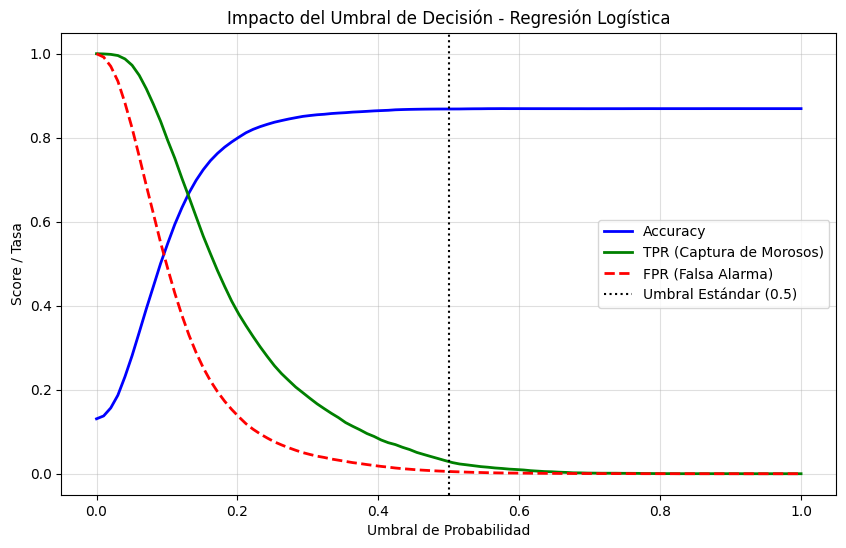

In [34]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# AJUSTE: Usamos el primer (o único) modelo que tengamos en el diccionario
nombre_modelo = list(mejores_modelos.keys())[0] 
print(f"Generando gráfica de umbrales para: {nombre_modelo}")

probs = mejores_modelos[nombre_modelo].predict_proba(X_test)[:, 1]

# El resto del código sigue igual...
umbrales = np.linspace(0, 1, 100)
l_accuracy = []
l_tpr = []
l_fpr = []

for u in umbrales:
    pred_u = (probs >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_u, labels=[0, 1]).ravel()
    l_accuracy.append(accuracy_score(y_test, pred_u))
    l_tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    l_fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

plt.figure(figsize=(10, 6))
plt.plot(umbrales, l_accuracy, label='Accuracy', color='blue', lw=2)
plt.plot(umbrales, l_tpr, label='TPR (Captura de Morosos)', color='green', lw=2)
plt.plot(umbrales, l_fpr, label='FPR (Falsa Alarma)', color='red', linestyle='--', lw=2)

plt.axvline(0.5, color='black', linestyle=':', label='Umbral Estándar (0.5)')
plt.title(f'Impacto del Umbral de Decisión - {nombre_modelo}')
plt.xlabel('Umbral de Probabilidad')
plt.ylabel('Score / Tasa')
plt.legend()
plt.grid(alpha=0.4)
plt.show()


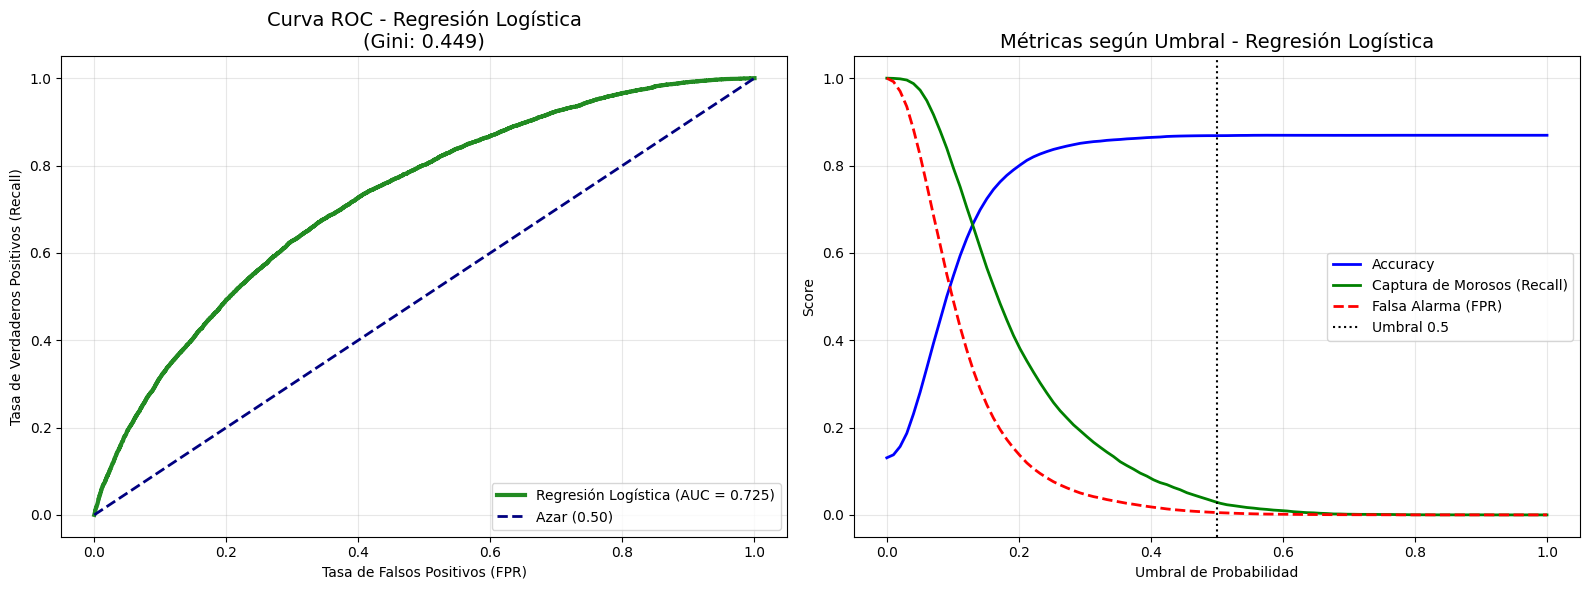

--- REPORTE FINAL ---
Modelo: Regresión Logística
Gini:   0.4490
Estado: REQUIERE MEJORA


In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
import numpy as np

# 1. DETECCIÓN DINÁMICA: Tomamos el primer (o único) modelo disponible
nombre_modelo_final = list(mejores_modelos.keys())[0]
modelo_final = mejores_modelos[nombre_modelo_final]

# Obtenemos datos para el gráfico
probs_final = modelo_final.predict_proba(X_test)[:, 1]
auc_val = roc_auc_score(y_test, probs_final)
gini_val = 2 * auc_val - 1

# Creamos una figura con dos paneles
plt.figure(figsize=(16, 6))

# --- PANEL 1: Curva ROC (Dinámica) ---
plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_test, probs_final)
plt.plot(fpr, tpr, color='forestgreen', lw=3, label=f'{nombre_modelo_final} (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (0.50)')
plt.title(f'Curva ROC - {nombre_modelo_final}\n(Gini: {gini_val:.3f})', fontsize=14)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# --- PANEL 2: Análisis de Umbrales (Dinámico) ---
plt.subplot(1, 2, 2)
umbrales = np.linspace(0, 1, 100)
l_acc, l_tpr, l_fpr = [], [], []

for u in umbrales:
    pred_u = (probs_final >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_u, labels=[0, 1]).ravel()
    l_acc.append(accuracy_score(y_test, pred_u))
    l_tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    l_fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

plt.plot(umbrales, l_acc, label='Accuracy', color='blue', lw=2)
plt.plot(umbrales, l_tpr, label='Captura de Morosos (Recall)', color='green', lw=2)
plt.plot(umbrales, l_fpr, label='Falsa Alarma (FPR)', color='red', linestyle='--', lw=2)
plt.axvline(0.5, color='black', linestyle=':', label='Umbral 0.5')
plt.title(f'Métricas según Umbral - {nombre_modelo_final}', fontsize=14)
plt.xlabel('Umbral de Probabilidad')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"--- REPORTE FINAL ---")
print(f"Modelo: {nombre_modelo_final}")
print(f"Gini:   {gini_val:.4f}")
print(f"Estado: {'APTO' if gini_val > 0.45 else 'REQUIERE MEJORA'}")


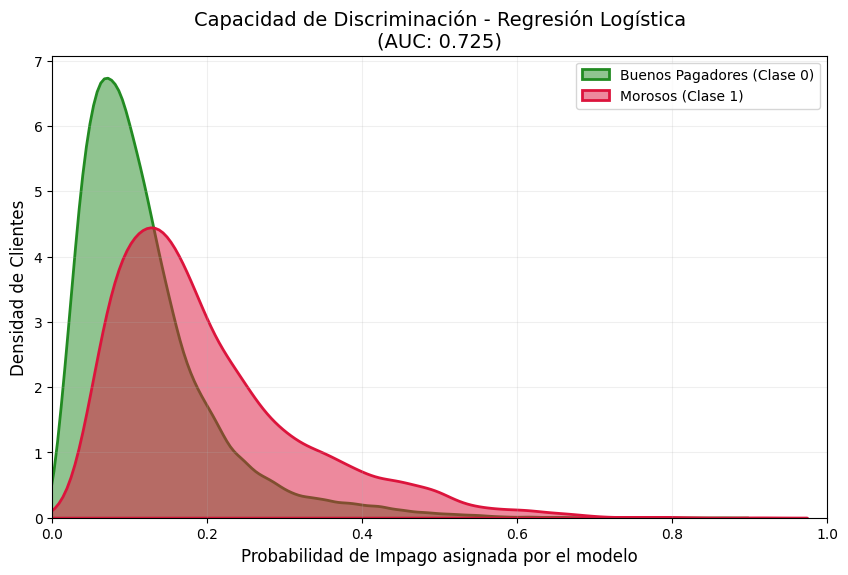

Interpretación para Regresión Logística:
 - El área VERDE son los clientes que el modelo identifica como bajo riesgo.
 - El área ROJA son los identificados como alto riesgo.
 - Cuanto más separadas estén las 'montañas', más eficiente es tu segmentación.


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# 1. Detección dinámica del modelo y probabilidades
nombre_mod = list(mejores_modelos.keys())[0]
y_probs = mejores_modelos[nombre_mod].predict_proba(X_test)[:, 1]
auc_val = roc_auc_score(y_test, y_probs)

# 2. Visualización de la separación de densidades
plt.figure(figsize=(10, 6))

# Graficamos la distribución
sns.kdeplot(y_probs[y_test == 0], label='Buenos Pagadores (Clase 0)', fill=True, color='forestgreen', alpha=0.5, lw=2)
sns.kdeplot(y_probs[y_test == 1], label='Morosos (Clase 1)', fill=True, color='crimson', alpha=0.5, lw=2)

# Estética dinámica usando 'nombre_mod'
plt.title(f'Capacidad de Discriminación - {nombre_mod}\n(AUC: {auc_val:.3f})', fontsize=14)
plt.xlabel('Probabilidad de Impago asignada por el modelo', fontsize=12)
plt.ylabel('Densidad de Clientes', fontsize=12)
plt.xlim(0, 1) 
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"Interpretación para {nombre_mod}:")
print(f" - El área VERDE son los clientes que el modelo identifica como bajo riesgo.")
print(f" - El área ROJA son los identificados como alto riesgo.")
print(f" - Cuanto más separadas estén las 'montañas', más eficiente es tu segmentación.")


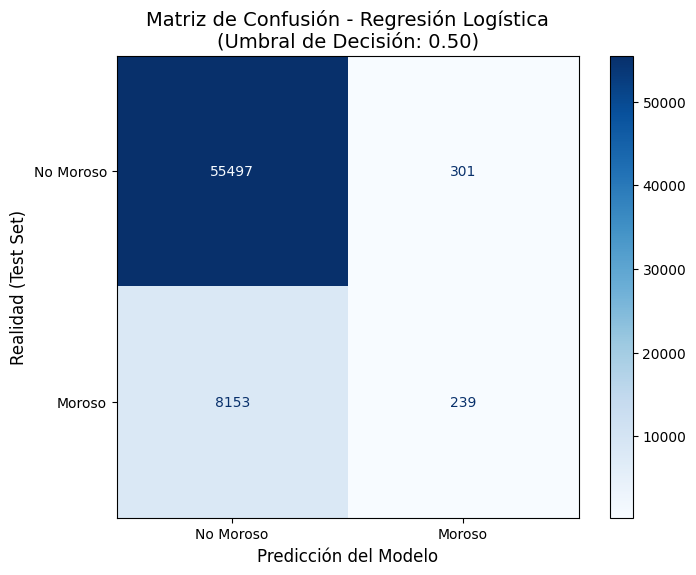

--- RESUMEN DE IMPACTO (Regresión Logística) ---
 - Clientes buenos detectados correctamente: 55,497
 - Morosos evitados con éxito: 239
 - Morosos que se nos escaparon (Peligro): 8,153
 - Clientes buenos rechazados por error: 301


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Detección dinámica del modelo y sus predicciones
nombre_mod = list(mejores_modelos.keys())[0]
y_pred = mejores_modelos[nombre_mod].predict(X_test)

# 2. Cálculo de la matriz
cm = confusion_matrix(y_test, y_pred)

# 3. Gráfico dinámico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Moroso', 'Moroso'])
disp.plot(cmap='Blues', values_format='d', ax=ax)

# Títulos dinámicos
plt.title(f'Matriz de Confusión - {nombre_mod}\n(Umbral de Decisión: 0.50)', fontsize=14)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Test Set)', fontsize=12)
plt.show()

# Resumen de impacto dinámico
tn, fp, fn, tp = cm.ravel()

print(f"--- RESUMEN DE IMPACTO ({nombre_mod}) ---")
print(f" - Clientes buenos detectados correctamente: {tn:,}")
print(f" - Morosos evitados con éxito: {tp:,}")
print(f" - Morosos que se nos escaparon (Peligro): {fn:,}")
print(f" - Clientes buenos rechazados por error: {fp:,}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Detección dinámica del modelo
nombre_mod = list(mejores_modelos.keys())[0]
modelo_final = mejores_modelos[nombre_mod]

# 2. Extracción de importancia (maneja tanto Coeficientes como Feature Importances)
if hasattr(modelo_final, 'coef_'):
    # Caso: Regresión Logística
    pesos = modelo_final.coef_[0]
    titulo_eje = 'Coeficiente (Peso en la decisión)'
    colores_logic = True
elif hasattr(modelo_final, 'feature_importances_'):
    # Caso: Random Forest, Árboles o XGBoost
    pesos = modelo_final.feature_importances_
    titulo_eje = 'Importancia Relativa'
    colores_logic = False
else:
    pesos = None

if pesos is not None:
    # Creamos el DataFrame de importancia
    coeficientes = pd.DataFrame({
        'Variable': X_train.columns,
        'Peso': pesos
    })

    # 3. Tomamos el Top 20 por valor absoluto
    coeficientes['Importancia_Abs'] = coeficientes['Peso'].abs()
    coeficientes = coeficientes.sort_values(by='Importancia_Abs', ascending=False).head(20)

    # 4. Graficamos
    plt.figure(figsize=(12, 8))
    
    if colores_logic:
        # Rojo para riesgo, Verde para protección
        palette = ['crimson' if x > 0 else 'forestgreen' for x in coeficientes['Peso']]
    else:
        # Azul para modelos de árboles (donde todo es positivo)
        palette = 'viridis'

    sns.barplot(x='Peso', y='Variable', data=coeficientes, palette=palette)

    plt.title(f'Top 20 Variables Determinantes - {nombre_mod}', fontsize=15)
    plt.xlabel(titulo_eje, fontsize=12)
    plt.ylabel('Variable', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

    if colores_logic:
        print("INTERPRETACIÓN:")
        print(" - En ROJO: Variables que INCREMENTAN el riesgo de impago.")
        print(" - En VERDE: Variables que REDUCEN el riesgo (perfil seguro).")
else:
    print(f"El modelo {nombre_mod} no soporta extracción de importancia de variables.")


In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# 1. Detección dinámica
nombre_mod = list(mejores_modelos.keys())[0]
# Usamos las probabilidades del modelo que esté seleccionado
y_probs = mejores_modelos[nombre_mod].predict_proba(X_test)[:, 1]

# 2. Cálculo de la curva de calibración
# n_bins=10 divide a los clientes en 10 grupos de riesgo
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

# 3. Gráfico dinámico
plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f'Modelo: {nombre_mod}', color='forestgreen')

# Línea de referencia (Calibración Perfecta)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración Perfecta')

plt.xlabel('Probabilidad Media Predicha', fontsize=12)
plt.ylabel('Frecuencia Real de Impagos (Realidad)', fontsize=12)
plt.title(f'Curva de Calibración - {nombre_mod}', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Fase 3: Si no nos pagan, ¿cuánto perdemos? (Modelo de Severidad - LGD)
Aquí cambia el juego. Coged solo a los clientes que sabemos que son morosos (Target de la PD = 1) y entrenad un modelo de regresión para predecir el porcentaje de pérdida (Loss).

- Entrenamiento: Nuevamente, usad el algoritmo de regresión que prefiráis.

- Métrica de Decisión: Evaluad con el MAE y el RMSE. ¿Qué modelo se acerca más al porcentaje real de pérdida que calculamos en la Fase 1?

In [ ]:
# Realizamos entrenamiento unicamente con clientes morosos
df_lgd = df[df['target_moroso'] == 1].copy()
print(f"Total cartera:     {len(df):,} préstamos")
print(f"Solo morosos (LGD): {len(df_lgd):,} préstamos")
print(f"% morosos:         {100 * len(df_lgd) / len(df):.1f}%")

In [ ]:
# Objetivo de la regresión
y_lgd = df_lgd['LGD_Real']

print(f"Target: LGD_Real (% de pérdida)")
print(f"  Media:   {y_lgd.mean():.1f}%")
print(f"  Mediana: {y_lgd.median():.1f}%")
print(f"  Min:     {y_lgd.min():.1f}%")
print(f"  Max:     {y_lgd.max():.1f}%")
print(f"  Nulos:   {y_lgd.isnull().sum()}")

**Interpretación de negocio:**
- La **mediana (28,8%)** es menor que la **media (40,4%)**: la mayoría de morosos tienen severidad moderada, pero un grupo pequeño con pérdidas muy altas **tira la media hacia arriba** (cola derecha).
- El **mínimo ~3%** indica defaults con recuperación casi total del capital.
- El **máximo 780%** refleja casos donde `saldo_maximo_adeudado` supera mucho el `EAD` original (intereses, moras, fees acumulados). Son **outliers históricos** en el target, no un error de nulos.
- Esta dispersión hace que el RMSE sea más exigente que el MAE y justifica **acotar las predicciones a [0, 100]%** en inferencia (Fase 4).
**Decisión:** usamos `LGD_Real` tal cual se calculó en Fase 1, sin recortar el target en entrenamiento, para ser fieles a la fórmula del enunciado.

In [ ]:
# OBSOLETA — usar la celda siguiente (predictores LGD con redundantes + cat_cols_lgd)

In [ ]:
# Matriz de correlación — solo numéricas + target LGD (morosos)
cols_corr_lgd = num_cols_lgd + ['LGD_Real']
corr_lgd = df_lgd[cols_corr_lgd].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_lgd, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlación numéricas vs LGD_Real (solo morosos)')
plt.tight_layout()
plt.show()

# Variables más correlacionadas con la severidad
correlaciones_lgd = corr_lgd['LGD_Real'].drop('LGD_Real').sort_values(key=abs, ascending=False)

print("--- Top 10 correlación con LGD_Real (por valor absoluto) ---")
print(correlaciones_lgd.head(10).to_string())

print("\n--- Top 5 positivas ---")
print(correlaciones_lgd.sort_values(ascending=False).head(5).to_string())

print("\n--- Top 5 negativas ---")
print(correlaciones_lgd.sort_values(ascending=True).head(5).to_string())

In [ ]:
# Predictores LGD: leakage + redundantes (solo morosos; PD no se toca)
cols_excluir_lgd = ['saldo_maximo_adeudado', 'LGD_Real', 'target_moroso']

cols_redundantes_lgd = [
    'tasa_interes',                              # → mantener grado
    'flag_meses_desde_ultima_mora_bancaria_na',    # → mantener flag_meses_desde_ultima_mora_na
    'flag_meses_desde_ultima_mora_revolvente_na',
    'num_lineas_credito_abiertas',               # → mantener num_total_lineas_credito
    'meses_desde_ultima_mora_bancaria',          # → mantener meses_desde_ultima_mora
    'meses_desde_ultima_mora_revolvente',
]

cols_quitar_lgd = cols_excluir_lgd + cols_redundantes_lgd
num_cols_lgd = [c for c in num_cols if c not in cols_quitar_lgd]

# Categóricas LGD (opcional pero recomendado: sin codigo_region)
cat_cols_lgd = [c for c in cat_cols if c != 'codigo_region']

predictores_lgd = num_cols_lgd + cat_cols_lgd
X_lgd = df_lgd[predictores_lgd]

print(f"Numéricas LGD:  {len(num_cols_lgd)} (antes {len([c for c in num_cols if c not in cols_excluir_lgd])})")
print(f"Categóricas:    {len(cat_cols_lgd)}")
print(f"Total columnas: {X_lgd.shape[1]} (antes de dummies)")
print(f"\n¿saldo_maximo en X? {'saldo_maximo_adeudado' in X_lgd.columns}")
print(f"¿Quitadas? {cols_redundantes_lgd}")

In [ ]:
# Separamos las muestras de train y test, en este punto no necesitamos estratificar porque todos son morosos
X_train_lgd_raw, X_test_lgd_raw, y_train_lgd, y_test_lgd = train_test_split(
    X_lgd, y_lgd, test_size=0.3, random_state=42
)

print(f"Train LGD: {X_train_lgd_raw.shape[0]:,} morosos ({100*len(y_train_lgd)/len(y_lgd):.1f}%)")
print(f"Test LGD:  {X_test_lgd_raw.shape[0]:,} morosos ({100*len(y_test_lgd)/len(y_lgd):.1f}%)")
print(f"\nLGD_Real train — media: {y_train_lgd.mean():.1f}% | mediana: {y_train_lgd.median():.1f}%")
print(f"LGD_Real test  — media: {y_test_lgd.mean():.1f}% | mediana: {y_test_lgd.median():.1f}%")

In [ ]:
X_train_lgd = pd.get_dummies(X_train_lgd_raw, columns=cat_cols_lgd, drop_first=True)
X_test_lgd = pd.get_dummies(X_test_lgd_raw, columns=cat_cols_lgd, drop_first=True)
X_test_lgd = X_test_lgd.reindex(columns=X_train_lgd.columns, fill_value=0)

print(f"Columnas tras dummies — train: {X_train_lgd.shape[1]} | test: {X_test_lgd.shape[1]}")
print(f"¿Mismas columnas? {list(X_train_lgd.columns) == list(X_test_lgd.columns)}")

In [ ]:
scaler_lgd = StandardScaler()

X_train_lgd = X_train_lgd.copy()
X_test_lgd = X_test_lgd.copy()

X_train_lgd[num_cols_lgd] = scaler_lgd.fit_transform(X_train_lgd[num_cols_lgd])
X_test_lgd[num_cols_lgd] = scaler_lgd.transform(X_test_lgd[num_cols_lgd])

print(f"Escaladas {len(num_cols_lgd)} columnas numéricas.")
print(f"Ejemplo EAD en train (tras escalar) — media: {X_train_lgd['EAD'].mean():.4f} | std: {X_train_lgd['EAD'].std():.4f}")

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

modelo_lgd_lr = LinearRegression()
modelo_lgd_lr.fit(X_train_lgd, y_train_lgd)

y_pred_lgd = modelo_lgd_lr.predict(X_test_lgd)
y_pred_lgd = np.clip(y_pred_lgd, 0, 100)

mae_lr = mean_absolute_error(y_test_lgd, y_pred_lgd)
rmse_lr = root_mean_squared_error(y_test_lgd, y_pred_lgd)

print(f"Regresión Lineal — MAE: {mae_lr:.2f} pp | RMSE: {rmse_lr:.2f} pp")

In [ ]:
# Baseline ingenuo: predecir siempre la media del train
baseline = np.full_like(y_test_lgd, y_train_lgd.mean())
mae_base = mean_absolute_error(y_test_lgd, baseline)
rmse_base = root_mean_squared_error(y_test_lgd, baseline)

print(f"Baseline (media) — MAE: {mae_base:.2f} pp | RMSE: {rmse_base:.2f} pp")
print(f"Regresión Lineal — MAE: {mae_lr:.2f} pp | RMSE: {rmse_lr:.2f} pp")
print(f"\nMejora MAE:  {mae_base - mae_lr:.2f} pp")
print(f"Mejora RMSE: {rmse_base - rmse_lr:.2f} pp")

modelo_lgd_champion = modelo_lgd_lr
nombre_lgd_champion = "Regresión Lineal"
print(f"\nChampion LGD: {nombre_lgd_champion}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nombre_mod = "Regresión Lineal"
modelo_final = modelo_lgd_lr  # o modelo_lgd_champion

# LinearRegression: coef_ es 1D (Logística usa coef_[0])
pesos = modelo_final.coef_

coeficientes = pd.DataFrame({
    'Variable': X_train_lgd.columns,
    'Peso': pesos
})

coeficientes['Importancia_Abs'] = coeficientes['Peso'].abs()
coeficientes = coeficientes.sort_values(by='Importancia_Abs', ascending=False).head(20)

plt.figure(figsize=(12, 8))
# Rojo = sube LGD predicho | Verde = baja LGD predicho
palette = ['crimson' if x > 0 else 'forestgreen' for x in coeficientes['Peso']]

sns.barplot(x='Peso', y='Variable', data=coeficientes, palette=palette)

plt.title(f'Top 20 Variables Determinantes - {nombre_mod} (LGD)', fontsize=15)
plt.xlabel('Coeficiente (impacto en % de severidad)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretación LGD:")
print(" - ROJO: al subir la variable, el modelo predice MAYOR pérdida (%)")
print(" - VERDE: al subir la variable, el modelo predice MENOR pérdida (%)")

In [ ]:
# ¿Cuántos morosos por estado en train?
print(df_lgd.loc[X_train_lgd_raw.index, 'estado_residencia'].value_counts().tail(10))

# Intercepto y rango de predicciones
print(f"Intercepto: {modelo_lgd_lr.intercept_:.2f}")
print(f"Pred min/max (antes clip): {modelo_lgd_lr.predict(X_test_lgd).min():.1f} / {modelo_lgd_lr.predict(X_test_lgd).max():.1f}")

# ¿estado y región duplican información?
print(df_lgd.groupby('estado_residencia')['codigo_region'].nunique().head())

## Resumen Fase 3 — Severidad (LGD)

| Paso | Acción | Resultado clave |
|------|--------|----------------|
| 1 | Filtrar morosos | 55.943 / 427.928 (13,1%) |
| 2 | Target `LGD_Real` | media 40,4% · mediana 28,8% · sin nulos |
| 3 | Predictores sin leakage | 34 cols · sin `saldo_maximo_adeudado` |
| 4 | Split 70/30 | train/test representativos (media ~40%) |
| 5 | One-Hot | 106 columnas alineadas |
| 6 | StandardScaler | 27 numéricas escaladas |
| 7–8 | Regresión Lineal | MAE 17,58 · RMSE 33,71 (vs baseline 23,74 / 42,12) |

**Champion:** `modelo_lgd_champion` = Regresión Lineal.

**Variables guardadas para Fase 4:** `modelo_lgd_champion`, `scaler_lgd`, `num_cols_lgd`, `cat_cols_lgd`, columnas de `X_train_lgd`.

In [ ]:
# Índices del test LGD (alineados con y_test_lgd y y_pred_lgd)
idx_test = y_test_lgd.index

comparacion = pd.DataFrame({
    'LGD_Real': y_test_lgd,
    'LGD_Predicho': y_pred_lgd,
}, index=idx_test)

comparacion['Error'] = comparacion['LGD_Real'] - comparacion['LGD_Predicho']
comparacion['Error_Abs'] = comparacion['Error'].abs()

# Datos originales del préstamo (EAD, grado, etc.)
comparacion = comparacion.join(df.loc[idx_test, ['EAD', 'grado', 'tasa_interes', 'ingreso_anual']])

print(comparacion.head(10).round(1))

In [ ]:
print("=== 5 predicciones MÁS acertadas ===")
print(comparacion.nsmallest(5, 'Error_Abs')[['EAD', 'grado', 'LGD_Real', 'LGD_Predicho', 'Error']].round(1))

print("\n=== 5 predicciones MÁS falladas ===")
print(comparacion.nlargest(5, 'Error_Abs')[['EAD', 'grado', 'LGD_Real', 'LGD_Predicho', 'Error']].round(1))

In [ ]:
# Elige un índice del test (o el peor error)
fila = comparacion.nlargest(1, 'Error_Abs').index[0]

print(f"--- Préstamo índice {fila} ---")
print(f"LGD real:      {df.loc[fila, 'LGD_Real']:.1f}%")
print(f"LGD predicho:  {y_pred_lgd[comparacion.index.get_loc(fila)]:.1f}%")
print(f"EAD:           ${df.loc[fila, 'EAD']:,.0f}")
print(f"Grado:         {df.loc[fila, 'grado']}")
print(f"Tasa interés:  {df.loc[fila, 'tasa_interes']:.2f}%")

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(comparacion['LGD_Real'], comparacion['LGD_Predicho'], alpha=0.2, s=10)
plt.plot([0, 100], [0, 100], 'r--', label='Predicción perfecta')
plt.xlabel("Real (%)")
plt.ylabel("Predicho (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Validación caso a caso (test LGD, n=16.783)

**Aciertos:** en morosos con LGD_Real entre ~8% y ~62%, el error es ~0 pp (ej. índices 180236, 394004).

**Peores casos:** 5 préstamos con EAD=$1.000 y LGD_Real 655–780%. El modelo predice 78–100% (límite económico). Error hasta ~689 pp.

**Conclusión:** el MAE (17,58 pp) refleja buen desempeño en casos típicos; el RMSE (33,71 pp) está inflado por outliers de severidad extrema. Para Fase 4 usamos LGD predicho en [0,100]%, coherente con la fórmula EL.

### Fase 4: El Veredicto Final (Expected Loss)
Ha llegado el momento de unir las piezas para el Comité de Dirección.

Tomad el conjunto de datos de Test (nuestra simulación del mundo real).

Usad el Modelo de PD para predecir la probabilidad de impago de cada préstamo.

Usad el Modelo de LGD para predecir el porcentaje de pérdida esperado.

Multiplicad los factores para calcular la pérdida esperada económica para cada cliente: 
$$
Pérdida\;Esperada = PD × (Loss / 100) × EAD
$$

Sumad la Pérdida Esperada de todos los clientes para obtener la cifra total de la cartera.

In [ ]:
modelo_pd = mejores_modelos['Regresión Logística']

pd_test = modelo_pd.predict_proba(X_test)[:, 1]

print(f"Préstamos en test PD: {len(pd_test):,}")
print(f"PD — media: {pd_test.mean():.3f} | min: {pd_test.min():.3f} | max: {pd_test.max():.3f}")

In [ ]:
# Mismo universo que PD: índices de X_test_raw
X_test_el_raw = X_test_raw[num_cols_lgd + cat_cols_lgd].copy()

X_test_el = pd.get_dummies(X_test_el_raw, columns=cat_cols_lgd, drop_first=True)
X_test_el = X_test_el.reindex(columns=X_train_lgd.columns, fill_value=0)

X_test_el[num_cols_lgd] = scaler_lgd.transform(X_test_el[num_cols_lgd])

lgd_test = np.clip(modelo_lgd_champion.predict(X_test_el), 0, 100)

print(f"LGD — media: {lgd_test.mean():.1f}% | mediana: {np.median(lgd_test):.1f}%")

In [ ]:
ead_test = df.loc[X_test_raw.index, 'EAD'].values

el_por_prestamo = pd_test * (lgd_test / 100) * ead_test

resultado_el = pd.DataFrame({
    'PD': pd_test,
    'LGD_pct': lgd_test,
    'EAD': ead_test,
    'EL': el_por_prestamo,
    'target_moroso': y_test.values,
}, index=X_test_raw.index)

print(resultado_el.head())

In [ ]:
valor_cartera_test = ead_test.sum()
el_total = el_por_prestamo.sum()

print("=" * 60)
print(f"Cartera test (EAD total):     ${valor_cartera_test:,.0f}  ({valor_cartera_test/1e6:.2f} M$)")
print(f"Pérdida esperada (EL total):  ${el_total:,.0f}  ({el_total/1e6:.2f} M$)")
print(f"EL / EAD cartera:             {100 * el_total / valor_cartera_test:.2f}%")
print("=" * 60)

## 📊 Entregable Final: La Defensa
El Notebook debe terminar con una sección de conclusiones respondiendo a esto:

"Señores del Comité, de una cartera de Test valorada en [X] millones de dólares, nuestro motor estima que tendremos unas pérdidas por impago de [Y] millones de dólares."

Justificad la elección de vuestros modelos. ¿Son explicables ante el regulador o habéis optado por maximizar la precisión a costa de usar cajas negras?

Demostradme que no sois simples picadores de código, sino verdaderos Data Scientists financieros.